# Análisis Exploratorio de Datos (EDA) - Propiedades Físicas de Galaxias MaNGA

**Equipo 61**

Gustavo Adolfo Morales García A00828432

Alejandro Jesús Mondragón Jiménez A01795837

Sebastián Ezequiel Coronado Rivera A01212824

## Contexto del Proyecto

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje profundo capaz de **inferir propiedades físicas de galaxias directamente desde imágenes astronómicas**, sin necesidad de realizar todo el procesamiento tradicional que normalmente se requiere para obtener estos datos.

### Origen de los Datos

Los datos provienen del proyecto **MaNGA (Mapping Nearby Galaxies at APO)**, que es parte del **Sloan Digital Sky Survey (SDSS)**. Este conjunto de datos contiene propiedades físicas y estructurales de galaxias cercanas, obtenidas mediante espectroscopía de campo integral (IFU).

### Variables del Conjunto de Datos

Las variables incluyen:

**Variables de identificación y posición:**
- `name`: Identificador único de la galaxia (formato: manga-XXXXX-XXXXX)
- `objra`: Ascensión recta (coordenada celestial en grados)
- `objdec`: Declinación (coordenada celestial en grados)

**Variables morfológicas (CAS):**
- `C`: Concentración - mide qué tan concentrada está la luz en el centro de la galaxia
- `A`: Asimetría - mide la asimetría rotacional de la galaxia
- `S`: Suavidad (Smoothness) - mide la irregularidad de la estructura

**Variables de masa y estructura:**
- `nsa_sersic_mass`: Masa estelar total (en masas solares)
- `LogMass`: Logaritmo de la masa estelar total
- `nsa_sersic_ba`: Relación de eje menor/mayor (elipticidad)
- `nsa_sersic_n`: Índice de Sersic (describe el perfil de brillo)
- `PETRO_TH90`: Radio de Petrosian al 90% de flujo

**Variables de formación estelar y composición:**
- `log_age_mean_LW`: Edad estelar media ponderada por luminosidad (logaritmo)
- `log_ZH_mean_LW`: Metalicidad media ponderada por luminosidad (logaritmo)
- `log_SFR_ssp`: Tasa de formación estelar de SSP (logaritmo)
- `log_SFR_Ha`: Tasa de formación estelar de H-alpha (logaritmo)

**Variables cinemáticas y fotométricas:**
- `vel_sigma_Re`: Dispersión de velocidad al radio efectivo
- `modelMag_r`: Magnitud modelo en banda r

## Objetivo del EDA

En este primer avance realizaremos un **análisis exploratorio exhaustivo** para:
1. Comprender la estructura y calidad de los datos
2. Identificar patrones, tendencias y relaciones entre variables
3. Detectar y manejar valores faltantes, atípicos y problemas de calidad
4. Preparar el conjunto de datos para el desarrollo del modelo de deep learning


In [1]:
# Importación de librerías necesarias
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

---

## 1. Carga y Descripción Inicial del Conjunto de Datos

En esta sección cargamos el archivo CSV y realizamos una inspección inicial para comprender:
- El tamaño del dataset (número de filas y columnas)
- Los tipos de datos de cada variable
- Una vista preliminar de los primeros registros

In [2]:
# Carga del archivo CSV con propiedades físicas de galaxias MaNGA
df = pd.read_csv('inferencia.csv')

# Mostrar las dimensiones del dataset
print(f"DIMENSIONES DEL DATASET")
print(f"Número de galaxias (filas): {df.shape[0]:,}")
print(f"Número de variables (columnas): {df.shape[1]}")

DIMENSIONES DEL DATASET
Número de galaxias (filas): 10,126
Número de variables (columnas): 17


In [3]:
# Vista previa de las primeras 10 filas del dataset
print("\nVISTA PREVIA DEL DATASET (primeras 10 galaxias):\n")
df.head(10)


VISTA PREVIA DEL DATASET (primeras 10 galaxias):



,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,133.3711,57.5984,2.419,0.191,0.26,3.0680e+09,9.4869,0.3353,0.7418,7.8809,8.5793,-0.6862,0.2797,-0.0895,0.7871,16.3824
1,manga-10001-12702,133.6857,57.4803,2.882,0.094,0.01,5.3416e+09,9.7277,0.5082,1.4427,14.1474,8.6074,-0.5342,0.0641,-0.6085,0.7881,16.6850
2,manga-10001-12703,136.0172,57.0923,3.249,0.135,0.43,1.3694e+10,10.1365,0.2057,2.1808,13.0018,8.7531,-0.3977,0.2267,0.1004,0.5039,15.6903
3,manga-10001-12704,133.9900,57.6780,3.380,0.212,0.85,4.2866e+09,9.6321,0.1500,0.8693,28.6829,8.7495,-0.5560,-0.3412,-0.4651,0.5194,14.6878
4,manga-10001-12705,136.7514,57.4514,2.883,0.152,0.15,1.2987e+10,10.1135,0.4715,1.2505,11.0396,8.5714,-0.6755,0.4678,0.4825,0.7696,15.7142
5,manga-10001-1901,133.3300,57.0412,2.709,0.140,0.18,1.3402e+09,9.1272,0.3335,0.7154,4.8629,9.0767,-0.2459,-0.8371,-0.8922,0.4456,17.2005
6,manga-10001-1902,134.1939,56.7867,3.964,0.100,-0.01,1.4535e+10,10.1624,0.7335,4.9523,12.3410,9.7670,-0.0747,-1.8509,-2.7075,0.1395,14.8354
7,manga-10001-3701,132.4656,57.1437,2.853,0.050,0.27,6.8655e+09,9.8367,0.6714,5.9563,4.5232,9.1803,-0.4393,-1.1397,-3.2127,0.1431,16.6792
8,manga-10001-3702,132.9128,57.1074,4.310,0.112,0.26,6.8592e+09,9.8363,0.8963,6.0000,13.0707,9.3457,-0.1532,-0.1689,-0.0564,0.1542,15.3195
9,manga-10001-3703,134.5915,57.6850,2.953,0.066,0.17,3.7466e+09,9.5736,0.3783,1.8669,5.5400,8.6239,-0.5629,0.0037,-0.1746,0.7017,16.7082


In [4]:
# Información detallada sobre tipos de datos y uso de memoria
print("\nINFORMACIÓN DETALLADA DEL DATASET:\n")
df.info()


INFORMACIÓN DETALLADA DEL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10126 entries, 0 to 10125
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             10126 non-null  object 
 1   objra            10126 non-null  float64
 2   objdec           10126 non-null  float64
 3   C                10126 non-null  float64
 4   A                10126 non-null  float64
 5   S                10126 non-null  float64
 6   nsa_sersic_mass  10125 non-null  float64
 7   LogMass          10098 non-null  float64
 8   nsa_sersic_ba    10125 non-null  float64
 9   nsa_sersic_n     10125 non-null  float64
 10  PETRO_TH90       10093 non-null  float64
 11  log_age_mean_LW  10080 non-null  float64
 12  log_ZH_mean_LW   10080 non-null  float64
 13  log_SFR_ssp      10063 non-null  float64
 14  log_SFR_Ha       9964 non-null   float64
 15  vel_sigma_Re     10074 non-null  float64
 16  modelMag_r       1011

---

## 2. Análisis de Valores Faltantes

### ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

Los valores faltantes pueden afectar significativamente el rendimiento de modelos de ML/DL. Es crucial:
- Identificar qué variables tienen valores faltantes
- Cuantificar el porcentaje de datos faltantes
- Detectar si hay patrones sistemáticos de ausencia
- Determinar la estrategia de imputación o eliminación más adecuada

In [5]:
# Cálculo de valores faltantes por columna
missing_data = pd.DataFrame({
    'Valores_Faltantes': df.isnull().sum(),  # Conteo de NaN por columna
    'Porcentaje': (df.isnull().sum() / len(df)) * 100  # Porcentaje de NaN
})

# Filtrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
)

print("\nANÁLISIS DE VALORES FALTANTES:\n")
print("\n")

if len(missing_data) > 0:
    print(missing_data)
    print("\n"*3)
    print(f"\nTotal de columnas con valores faltantes: {len(missing_data)}")
    print(f"Máximo porcentaje de valores faltantes: {missing_data['Porcentaje'].max():.2f}%")
else:
    print("No se detectaron valores faltantes (NaN) en el dataset.")


ANÁLISIS DE VALORES FALTANTES:



                 Valores_Faltantes  Porcentaje
log_SFR_Ha                     162      1.5998
log_SFR_ssp                     63      0.6222
vel_sigma_Re                    52      0.5135
log_age_mean_LW                 46      0.4543
log_ZH_mean_LW                  46      0.4543
PETRO_TH90                      33      0.3259
LogMass                         28      0.2765
modelMag_r                       9      0.0889
nsa_sersic_mass                  1      0.0099
nsa_sersic_ba                    1      0.0099
nsa_sersic_n                     1      0.0099





Total de columnas con valores faltantes: 11
Máximo porcentaje de valores faltantes: 1.60%


In [6]:
# Detección de valores placeholder (valores centinela como -999, -9999)
# Estos valores suelen usarse para indicar "dato no disponible" en lugar de NaN

print("\nBÚSQUEDA DE VALORES PLACEHOLDER (centinela):")
print("\n")
print("Analizando valores extremadamente negativos que puedan indicar datos faltantes...\n")

# Seleccionar solo columnas numéricas para análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

placeholder_report = []  # Lista para almacenar resultados

# Iterar sobre cada columna numérica
for col in numeric_cols:
    # Buscar valores menores a -100 (threshold para placeholders)
    placeholder_mask = df[col] < -100
    n_placeholders = placeholder_mask.sum()

    if n_placeholders > 0:
        # Identificar valores únicos que son placeholders
        unique_placeholders = df.loc[placeholder_mask, col].unique()
        percentage = (n_placeholders / len(df)) * 100

        placeholder_report.append({
            'Columna': col,
            'N_Placeholders': n_placeholders,
            'Porcentaje': percentage,
            'Valores_Únicos': unique_placeholders
        })

# Mostrar resultados
if placeholder_report:
    for item in placeholder_report:
        print(f"Columna: {item['Columna']}")
        print(f"  - Registros con placeholder: {item['N_Placeholders']:,} ({item['Porcentaje']:.2f}%)")
        print(f"  - Valores placeholder encontrados: {item['Valores_Únicos']}")
        print()

    print("\n")
    print("CONCLUSIÓN: Se detectaron valores placeholder que deben tratarse como faltantes.")
else:
    print("No se detectaron valores placeholder en el rango analizado.")

print("\n")


BÚSQUEDA DE VALORES PLACEHOLDER (centinela):


Analizando valores extremadamente negativos que puedan indicar datos faltantes...

Columna: C
  - Registros con placeholder: 34 (0.34%)
  - Valores placeholder encontrados: [-999.]

Columna: A
  - Registros con placeholder: 34 (0.34%)
  - Valores placeholder encontrados: [-999.]

Columna: S
  - Registros con placeholder: 36 (0.36%)
  - Valores placeholder encontrados: [-999.   -102.97 -118.68]

Columna: nsa_sersic_mass
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]

Columna: nsa_sersic_ba
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]

Columna: nsa_sersic_n
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]



CONCLUSIÓN: Se detectaron valores placeholder que deben tratarse como faltantes.




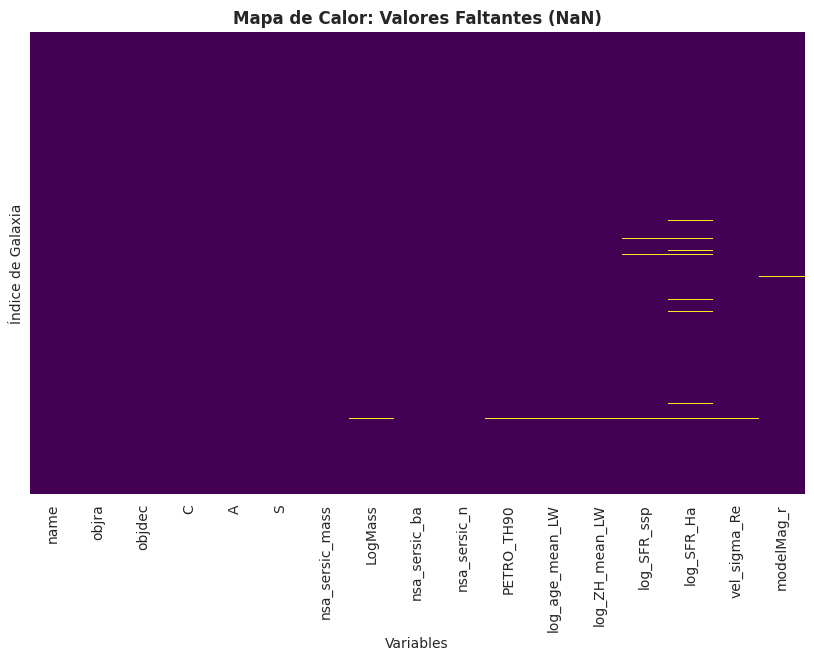

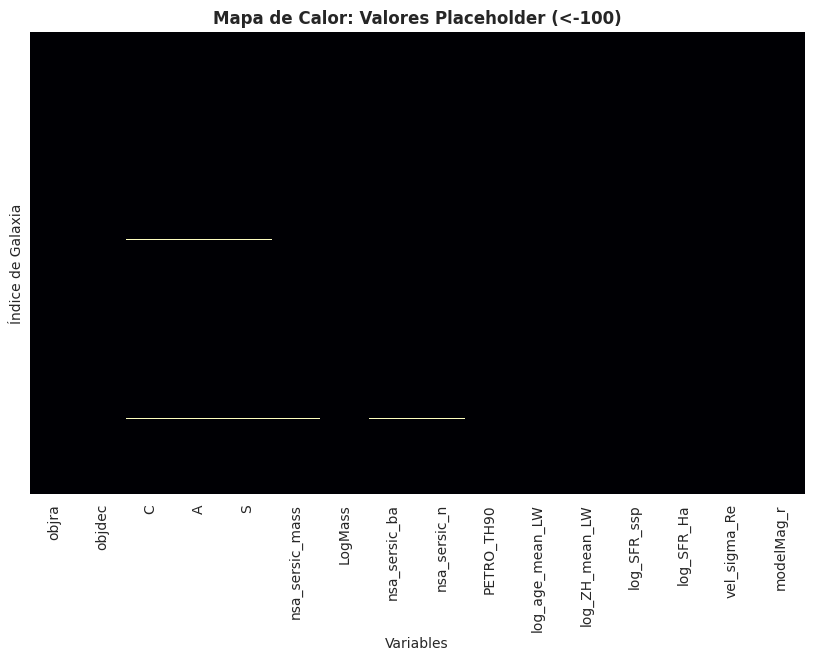


 Interpretación de los mapas de calor:
  - Áreas oscuras = datos presentes/válidos
  - Áreas claras/brillantes = datos faltantes/placeholder


In [7]:
# Visualización de valores faltantes y placeholders
if len(missing_data) > 0 or placeholder_report:

    # --- Gráfica 1: Mapa de calor de valores faltantes NaN ---
    plt.figure(figsize=(10, 6)) # Crea una ventana nueva
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Mapa de Calor: Valores Faltantes (NaN)', fontsize=12, fontweight='bold')
    plt.xlabel('Variables')
    plt.ylabel('Índice de Galaxia')
    plt.show() # Muestra la primera gráfica

    # --- Gráfica 2: Mapa de calor de valores placeholder ---
    plt.figure(figsize=(10, 6)) # Crea otra ventana nueva
    placeholder_mask_df = pd.DataFrame(
        {col: df[col] < -100 for col in numeric_cols}
    )

    sns.heatmap(placeholder_mask_df, cbar=False, yticklabels=False, cmap='magma')
    plt.title('Mapa de Calor: Valores Placeholder (<-100)', fontsize=12, fontweight='bold')
    plt.xlabel('Variables')
    plt.ylabel('Índice de Galaxia')
    plt.show() # Muestra la segunda gráfica

    print("\n Interpretación de los mapas de calor:")
    print("  - Áreas oscuras = datos presentes/válidos")
    print("  - Áreas claras/brillantes = datos faltantes/placeholder")
else:
    print("\n No se requiere visualización: dataset sin valores faltantes detectados.")

---

## 3. Estadísticas Descriptivas del Conjunto de Datos

### ¿Cuáles son las estadísticas resumidas del conjunto de datos?

Las estadísticas descriptivas nos proporcionan una comprensión cuantitativa de:
- Tendencia central (media, mediana)
- Dispersión (desviación estándar, rango)
- Forma de distribución (asimetría, curtosis)
- Valores extremos (mínimos, máximos)

In [8]:
# Estadísticas descriptivas básicas
print("\nESTADÍSTICAS DESCRIPTIVAS BÁSICAS:\n")
print("\n")
df.describe()


ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:





,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
count,10126.0000,10126.0000,10126.0000,10126.0000,10126.0000,1.0125e+04,10098.0000,10125.0000,10125.0000,10093.0000,10080.0000,10080.0000,10063.0000,9964.0000,10074.0000,10117.0000
mean,183.1383,28.6249,-0.0989,-3.1801,-3.2031,4.6741e+10,10.1618,-26.0640,-23.4262,15.4045,9.0625,-0.3590,-0.3124,-0.8551,0.3770,15.5701
std,76.3018,17.9684,57.9862,57.8048,57.8662,2.6602e+11,0.7189,515.7138,515.8539,10.5067,0.4203,0.2508,0.7135,1.2628,0.2003,1.0639
min,0.0088,-9.3024,-999.0000,-999.0000,-999.0000,-9.9990e+03,5.9125,-9999.0000,-9999.0000,0.2234,7.7808,-1.7387,-3.8305,-5.3752,-1.0000,11.4271
25%,128.8919,14.6527,2.8660,0.0840,0.0700,3.8402e+09,9.5899,0.4332,1.3808,9.3241,8.7192,-0.5195,-0.8196,-1.5960,0.2338,14.8240
50%,194.1075,29.3681,3.2240,0.1320,0.1600,1.5474e+10,10.1934,0.6281,2.8151,12.9932,9.0469,-0.3216,-0.2785,-0.5618,0.3744,15.6097
75%,239.6892,43.8665,3.6550,0.2180,0.3100,5.5613e+10,10.7481,0.7815,5.4566,18.5098,9.4258,-0.1647,0.2221,0.0763,0.5087,16.2270
max,359.8586,65.2897,5.5990,1.9710,8.6300,2.4568e+13,13.3904,1.0000,6.0000,148.0084,9.8770,0.1483,2.3041,3.8996,1.0850,24.8020


In [9]:
# Estadísticas extendidas: asimetría y curtosis
print("\nESTADÍSTICAS EXTENDIDAS (Asimetría y Curtosis):\n")
print("\n")

# Calcular estadísticas avanzadas para columnas numéricas
extended_stats = pd.DataFrame({
    'Media': df[numeric_cols].mean(),  # Promedio
    'Mediana': df[numeric_cols].median(),  # Valor central
    'Desv_Est': df[numeric_cols].std(),  # Dispersión
    'Asimetría': df[numeric_cols].apply(lambda x: skew(x.dropna())),  # Skewness
    'Curtosis': df[numeric_cols].apply(lambda x: kurtosis(x.dropna())),  # Kurtosis
    'Min': df[numeric_cols].min(),  # Mínimo
    'Max': df[numeric_cols].max()  # Máximo
})

# Redondear para mejor legibilidad
extended_stats = extended_stats.round(4)

print(extended_stats)
print("\n"*2)

# Interpretación de asimetría
print("\nInterpretación de Asimetría (Skewness):")
print("  - Asimetría ≈ 0: Distribución simétrica (normal)")
print("  - Asimetría > 0: Sesgada a la derecha (cola derecha larga)")
print("  - Asimetría < 0: Sesgada a la izquierda (cola izquierda larga)")
print("\nInterpretación de Curtosis:")
print("  - Curtosis ≈ 0: Forma similar a distribución normal")
print("  - Curtosis > 0: Más puntiaguda que la normal (leptocúrtica)")
print("  - Curtosis < 0: Más plana que la normal (platicúrtica)")


ESTADÍSTICAS EXTENDIDAS (Asimetría y Curtosis):



                      Media     Mediana    Desv_Est  Asimetría   Curtosis  \
objra            1.8314e+02  1.9411e+02  7.6302e+01    -0.1666    -0.0845   
objdec           2.8625e+01  2.9368e+01  1.7968e+01    -0.3165    -0.9638   
C               -9.8900e-02  3.2240e+00  5.7986e+01   -17.1670   292.7453   
A               -3.1801e+00  1.3200e-01  5.7805e+01   -17.1692   292.7974   
S               -3.2031e+00  1.6000e-01  5.7866e+01   -17.1160   291.5198   
nsa_sersic_mass  4.6741e+10  1.5474e+10  2.6602e+11    79.5959  7181.0124   
LogMass          1.0162e+01  1.0193e+01  7.1890e-01    -0.1774    -0.6043   
nsa_sersic_ba   -2.6064e+01  6.2810e-01  5.1571e+02   -19.2874   370.0025   
nsa_sersic_n    -2.3426e+01  2.8151e+00  5.1585e+02   -19.2869   369.9919   
PETRO_TH90       1.5405e+01  1.2993e+01  1.0507e+01     4.0298    29.8591   
log_age_mean_LW  9.0625e+00  9.0469e+00  4.2030e-01    -0.0378    -1.0094   
log_ZH_mean_LW  -3.5900e

---

## 4. Detección de Valores Atípicos (Outliers)

### ¿Hay valores atípicos en el conjunto de datos?

Los valores atípicos pueden:
- Ser errores de medición o entrada de datos
- Representar fenómenos genuinos pero raros
- Afectar significativamente modelos de ML

Utilizaremos dos métodos complementarios:
1. **Método IQR (Rango Intercuartílico)**: Define outliers como valores fuera de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
2. **Método Z-Score**: Identifica valores con más de 3 desviaciones estándar de la media

In [10]:
# Detección de outliers usando el método IQR
print("\nDETECCIÓN DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico):\n")
print("\n")

# Crear DataFrame para almacenar resultados
outlier_summary_iqr = []

for col in numeric_cols:
    # Filtrar valores válidos (excluir placeholders)
    valid_data = df[col][df[col] > -100]

    # Calcular cuartiles
    Q1 = valid_data.quantile(0.25)  # Primer cuartil
    Q3 = valid_data.quantile(0.75)  # Tercer cuartil
    IQR = Q3 - Q1  # Rango intercuartílico

    # Definir límites para outliers
    lower_bound = Q1 - 1.5 * IQR  # Límite inferior
    upper_bound = Q3 + 1.5 * IQR  # Límite superior

    # Identificar outliers
    outliers_mask = (valid_data < lower_bound) | (valid_data > upper_bound)
    n_outliers = outliers_mask.sum()

    if n_outliers > 0:
        percentage = (n_outliers / len(valid_data)) * 100
        outlier_summary_iqr.append({
            'Columna': col,
            'N_Outliers': n_outliers,
            'Porcentaje': percentage,
            'Límite_Inferior': lower_bound,
            'Límite_Superior': upper_bound
        })

# Mostrar resultados
if outlier_summary_iqr:
    outlier_df_iqr = pd.DataFrame(outlier_summary_iqr)
    outlier_df_iqr = outlier_df_iqr.sort_values('Porcentaje', ascending=False)
    print(outlier_df_iqr.to_string(index=False))
    print("\n")
    print(f"\nTotal de variables con outliers: {len(outlier_summary_iqr)}")
else:
    print("No se detectaron outliers significativos usando el método IQR.")



DETECCIÓN DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico):



        Columna  N_Outliers  Porcentaje  Límite_Inferior  Límite_Superior
              S         965      9.5639      -2.9000e-01       6.7000e-01
nsa_sersic_mass         892      8.8334      -7.4261e+10       1.3414e+11
              A         733      7.2632      -1.1600e-01       4.2000e-01
     PETRO_TH90         480      4.7558      -4.4545e+00       3.2288e+01
     log_SFR_Ha         168      1.6861      -4.1044e+00       2.5847e+00
              C         152      1.5061       1.6870e+00       4.8390e+00
     modelMag_r         115      1.1367       1.2719e+01       1.8332e+01
 log_ZH_mean_LW          90      0.8929      -1.0517e+00       3.6746e-01
   vel_sigma_Re          62      0.6154      -1.7848e-01       9.2103e-01
    log_SFR_ssp          18      0.1789      -2.3821e+00       1.7845e+00
        LogMass          12      0.1188       7.8527e+00       1.2485e+01



Total de variables con outliers: 11


In [11]:
# Detección de outliers usando Z-Score
print("\nDETECCIÓN DE OUTLIERS - MÉTODO Z-SCORE (|Z| > 3):\n")
print("\n")

outlier_summary_zscore = []

for col in numeric_cols:
    # Filtrar valores válidos
    valid_data = df[col][df[col] > -100]

    # Calcular Z-score
    z_scores = np.abs(stats.zscore(valid_data.dropna()))

    # Identificar outliers (|Z| > 3)
    n_outliers = (z_scores > 3).sum()

    if n_outliers > 0:
        percentage = (n_outliers / len(valid_data.dropna())) * 100
        outlier_summary_zscore.append({
            'Columna': col,
            'N_Outliers': n_outliers,
            'Porcentaje': percentage
        })

# Mostrar resultados
if outlier_summary_zscore:
    outlier_df_zscore = pd.DataFrame(outlier_summary_zscore)
    outlier_df_zscore = outlier_df_zscore.sort_values('Porcentaje', ascending=False)
    print(outlier_df_zscore.to_string(index=False))
    print("\n")
else:
    print("No se detectaron outliers extremos usando Z-Score > 3.")



DETECCIÓN DE OUTLIERS - MÉTODO Z-SCORE (|Z| > 3):



        Columna  N_Outliers  Porcentaje
     PETRO_TH90         169      1.6744
     modelMag_r          88      0.8698
              A          87      0.8621
              C          82      0.8125
 log_ZH_mean_LW          56      0.5556
     log_SFR_Ha          50      0.5018
   vel_sigma_Re          38      0.3772
              S          28      0.2775
    log_SFR_ssp          17      0.1689
        LogMass          14      0.1386
nsa_sersic_mass           9      0.0891
log_age_mean_LW           1      0.0099





VISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS:



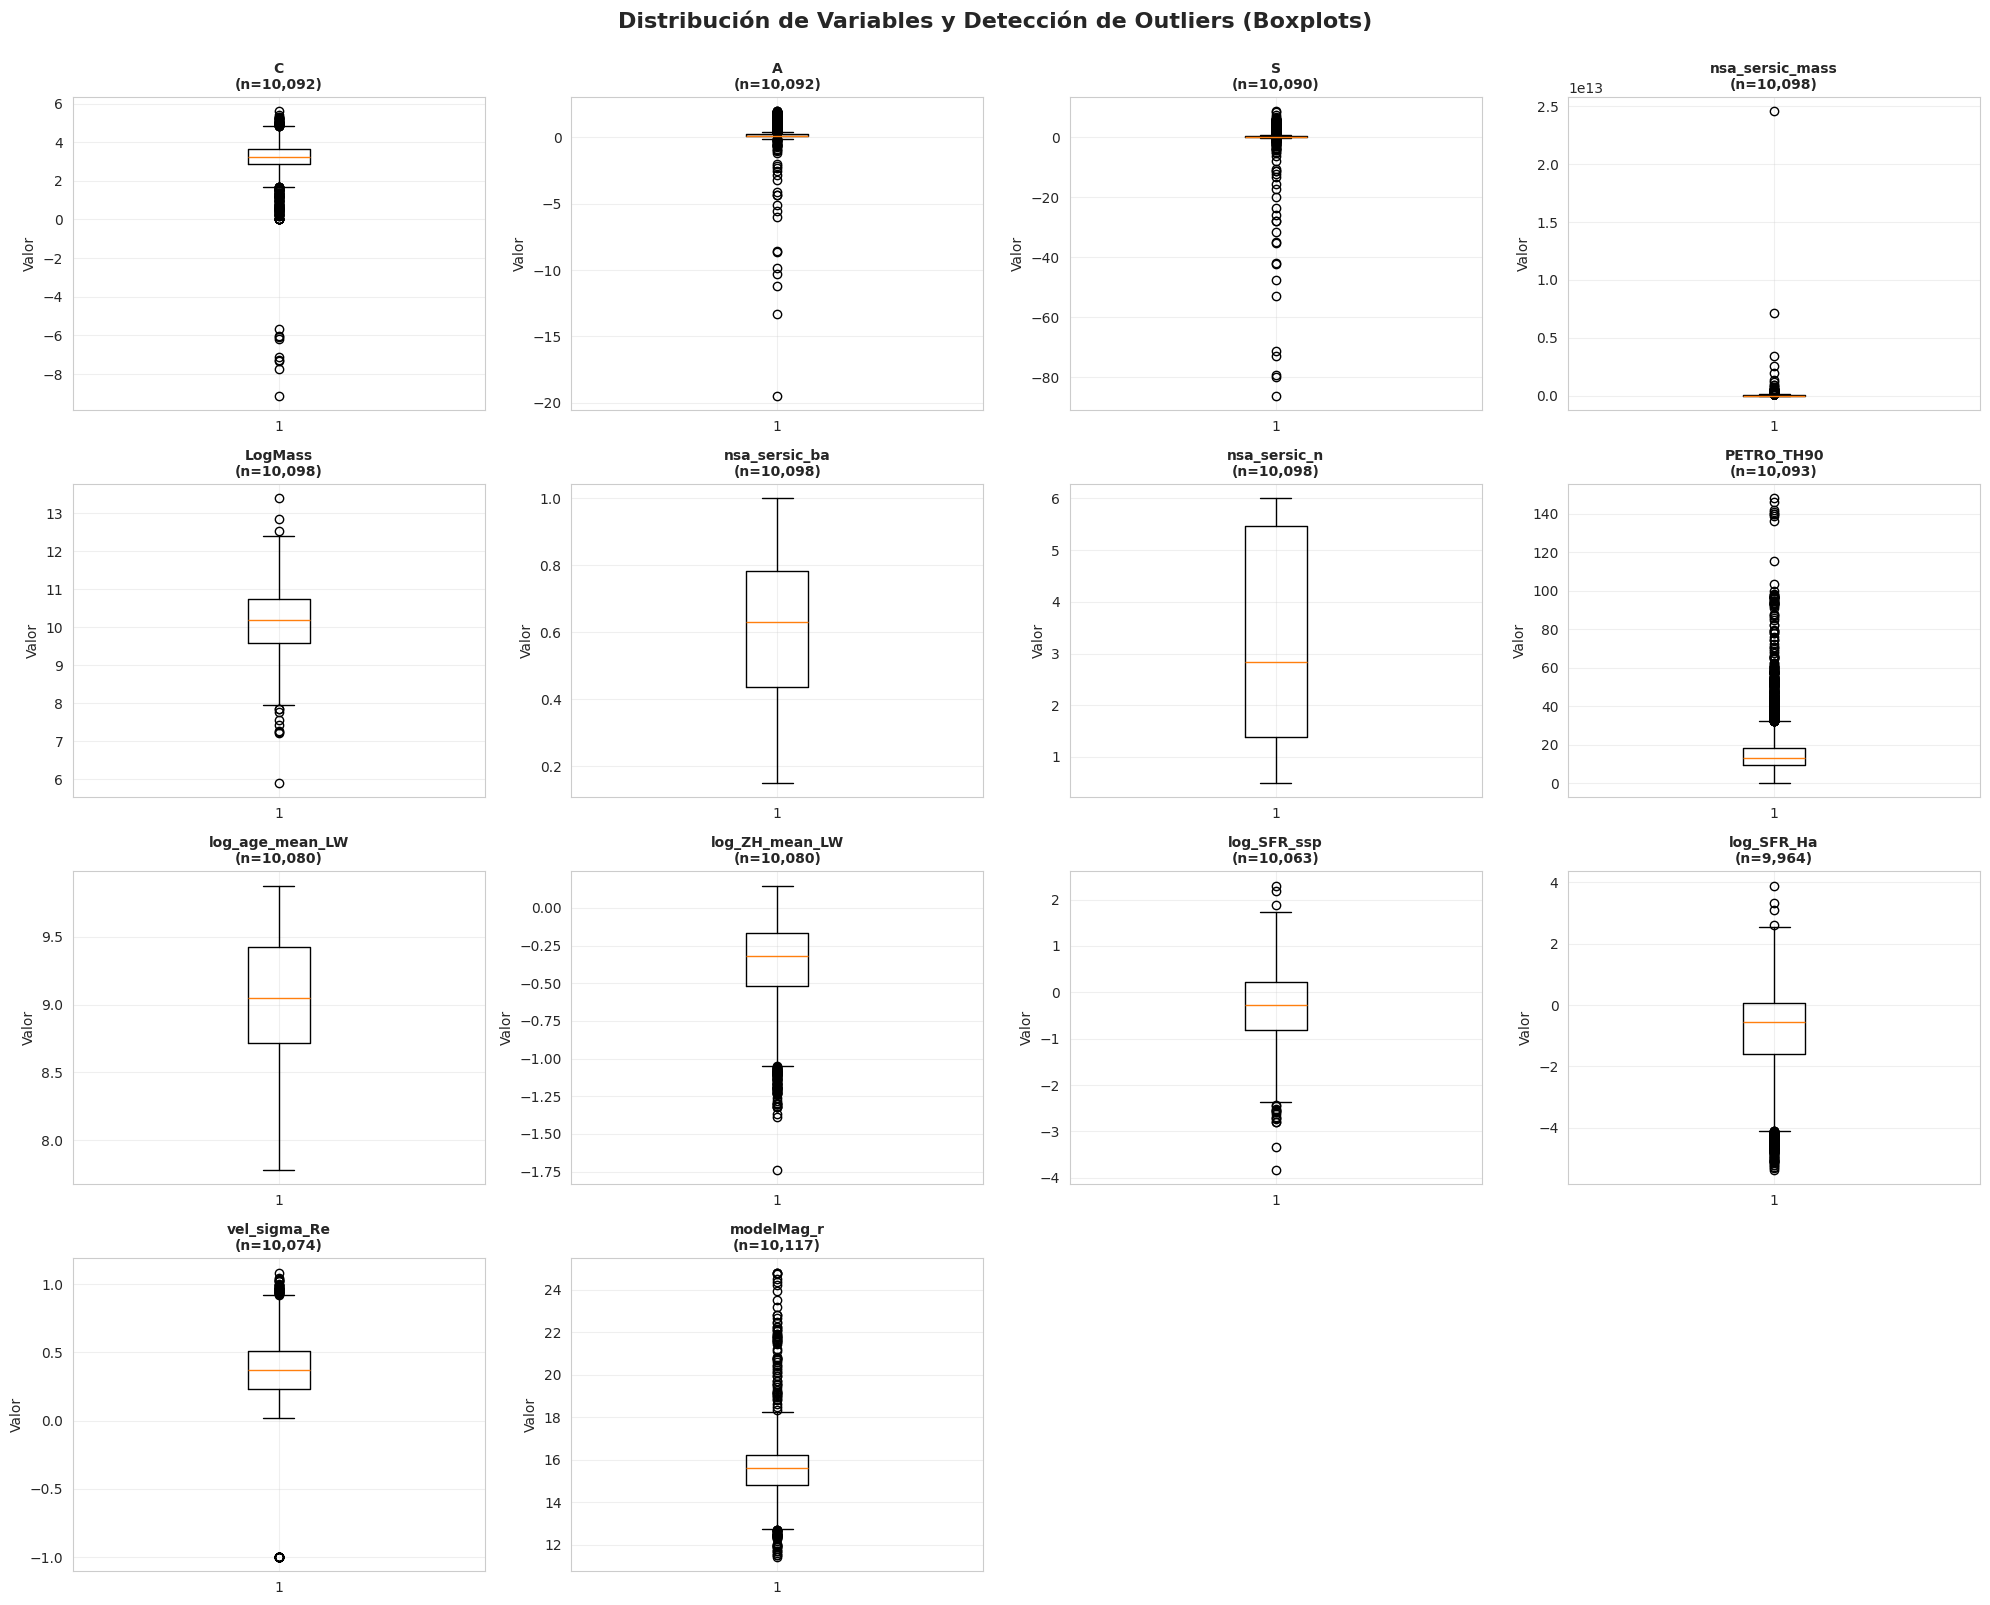


Interpretación de Boxplots:
  - Caja: Contiene el 50% central de los datos (Q1 a Q3)
  - Línea central: Mediana
  - Bigotes: Extienden hasta 1.5×IQR desde los cuartiles
  - Puntos fuera de bigotes: Outliers potenciales


In [12]:
# Visualización de outliers con boxplots
print("\nVISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS:\n")

# Seleccionar columnas clave para visualización (excluyendo coordenadas)
key_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]

# Crear subplots para boxplots
n_cols = 4  # Número de columnas en la cuadrícula
n_rows = int(np.ceil(len(key_cols) / n_cols))  # Calcular filas necesarias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  # Aplanar array de axes para fácil iteración

for idx, col in enumerate(key_cols):
    # Filtrar datos válidos para la columna
    valid_data = df[col][df[col] > -100].dropna()

    # Crear boxplot
    axes[idx].boxplot(valid_data, vert=True)
    axes[idx].set_title(f'{col}\n(n={len(valid_data):,})', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(key_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribución de Variables y Detección de Outliers (Boxplots)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nInterpretación de Boxplots:")
print("  - Caja: Contiene el 50% central de los datos (Q1 a Q3)")
print("  - Línea central: Mediana")
print("  - Bigotes: Extienden hasta 1.5×IQR desde los cuartiles")
print("  - Puntos fuera de bigotes: Outliers potenciales")

---

## 5. Análisis de Cardinalidad de Variables Categóricas

### ¿Cuál es la cardinalidad de las variables categóricas?

La cardinalidad (número de valores únicos) de variables categóricas es importante porque:
- Alta cardinalidad puede causar problemas en encoding
- Puede indicar si una variable es útil para clasificación/agrupación
- Afecta la complejidad computacional del modelo

In [13]:
# Análisis de cardinalidad
print("\nANÁLISIS DE CARDINALIDAD:\n")

# Identificar columnas categóricas (tipo object o string)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    cardinality_report = pd.DataFrame({
        'Columna': categorical_cols,
        'Valores_Únicos': [df[col].nunique() for col in categorical_cols],
        'Cardinalidad_%': [(df[col].nunique() / len(df)) * 100 for col in categorical_cols]
    })

    cardinality_report = cardinality_report.sort_values('Valores_Únicos', ascending=False)
    print(cardinality_report.to_string(index=False))

    # Clasificación de cardinalidad
    print("\nClasificación de Cardinalidad:")
    for _, row in cardinality_report.iterrows():
        col = row['Columna']
        card = row['Valores_Únicos']

        if card == len(df):
            category = "IDENTIFICADOR ÚNICO"
        elif card > len(df) * 0.5:
            category = "CARDINALIDAD MUY ALTA"
        elif card > 50:
            category = "CARDINALIDAD ALTA"
        elif card > 10:
            category = "CARDINALIDAD MEDIA"
        else:
            category = "CARDINALIDAD BAJA"

        print(f"  - {col}: {card:,} valores únicos - {category}")
else:
    print("No se detectaron variables categóricas (tipo object) en el dataset.")
    print("El dataset contiene principalmente variables numéricas.")
    print("\n\n")

# Análisis de la variable 'name' (identificador)
print("\n\n\nANÁLISIS DE IDENTIFICADORES (columna 'name'):\n")
print(f"Total de galaxias: {len(df):,}")
print(f"IDs únicos: {df['name'].nunique():,}")
print(f"IDs duplicados: {len(df) - df['name'].nunique():,}")

if df['name'].nunique() == len(df):
    print("\nCada galaxia tiene un identificador único.")
else:
    print("\nHay IDs duplicados en el dataset.")
    duplicates = df[df.duplicated(subset=['name'], keep=False)]
    print(f"   Registros duplicados: {len(duplicates):,}")



ANÁLISIS DE CARDINALIDAD:

Columna  Valores_Únicos  Cardinalidad_%
   name           10126           100.0

Clasificación de Cardinalidad:
  - name: 10,126 valores únicos - IDENTIFICADOR ÚNICO



ANÁLISIS DE IDENTIFICADORES (columna 'name'):

Total de galaxias: 10,126
IDs únicos: 10,126
IDs duplicados: 0

Cada galaxia tiene un identificador único.


---

## 6. Análisis de Distribuciones y Transformaciones

### ¿Existen distribuciones sesgadas? ¿Necesitamos aplicar transformaciones no lineales?

Muchos algoritmos de ML asumen distribuciones aproximadamente normales. Transformaciones como:
- **Log**: Para reducir asimetría positiva
- **Box-Cox**: Para normalizar distribuciones
- **Escalado**: Para poner variables en rangos comparables

pueden mejorar significativamente el rendimiento del modelo.


ANÁLISIS DE DISTRIBUCIONES (Histogramas):



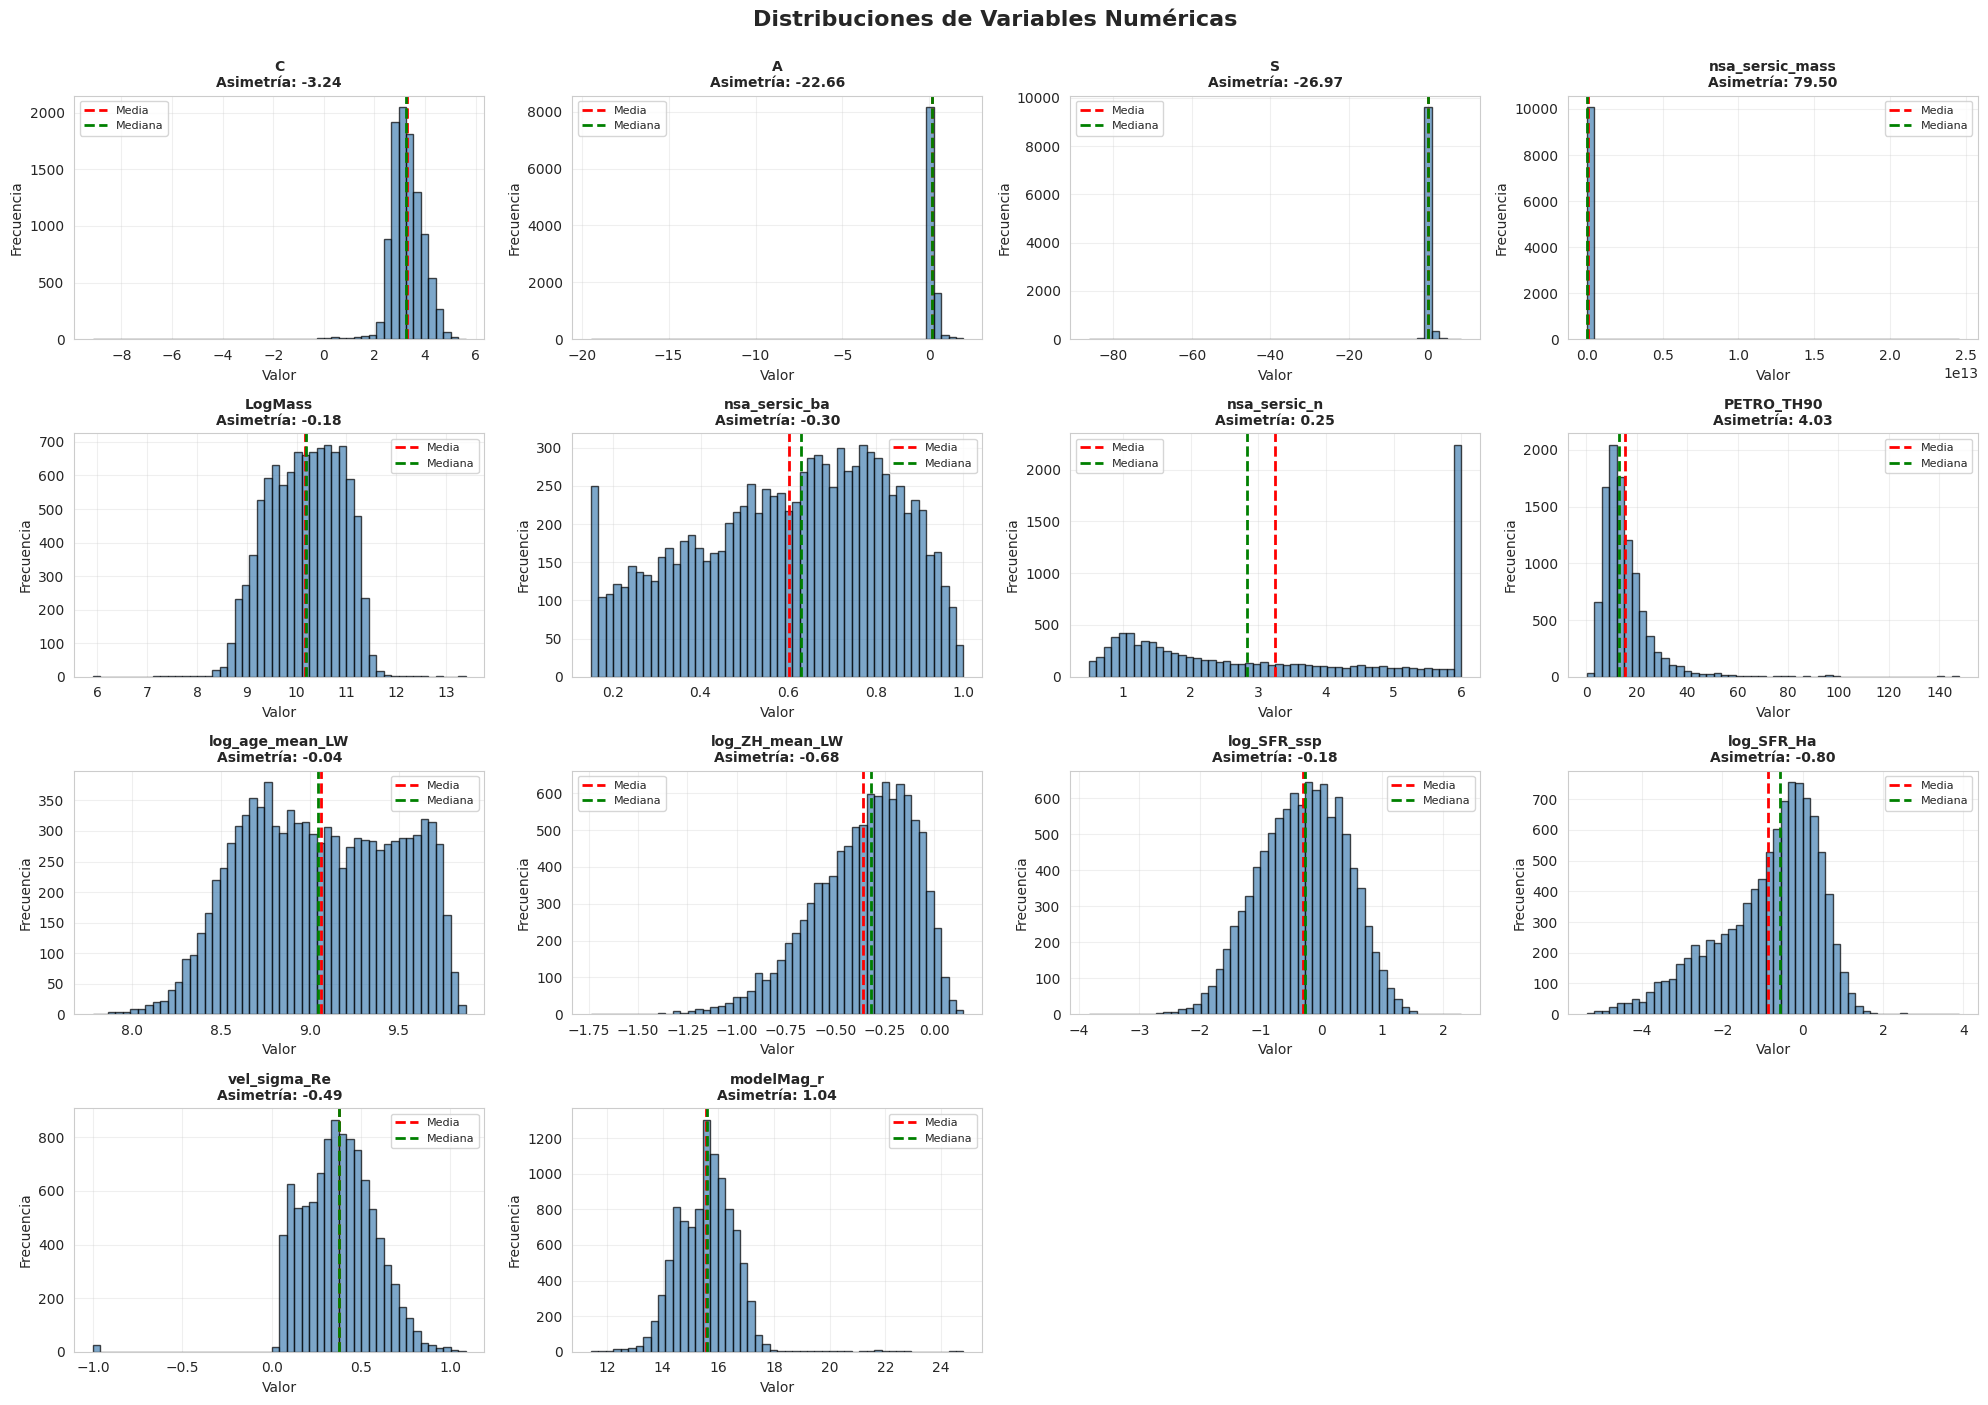


Interpretación de Asimetría en los Histogramas:
  - Asimetría ≈ 0: Distribución simétrica (líneas roja y verde coinciden)
  - Asimetría > 1: Fuertemente sesgada a la derecha
  - Asimetría < -1: Fuertemente sesgada a la izquierda


In [14]:
# Visualización de distribuciones con histogramas
print("\nANÁLISIS DE DISTRIBUCIONES (Histogramas):\n")

# Seleccionar columnas clave (excluyendo coordenadas)
dist_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]

# Configurar subplots
n_cols_grid = 4
n_rows_grid = int(np.ceil(len(dist_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3.5))
axes = axes.flatten()

for idx, col in enumerate(dist_cols):
    # Filtrar datos válidos
    valid_data = df[col][df[col] > -100].dropna()

    # Calcular asimetría
    skewness = skew(valid_data)

    # Crear histograma
    axes[idx].hist(valid_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].axvline(valid_data.mean(), color='red', linestyle='--', linewidth=2, label='Media')
    axes[idx].axvline(valid_data.median(), color='green', linestyle='--', linewidth=2, label='Mediana')

    # Título con información de asimetría
    axes[idx].set_title(f'{col}\nAsimetría: {skewness:.2f}', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(dist_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nInterpretación de Asimetría en los Histogramas:")
print("  - Asimetría ≈ 0: Distribución simétrica (líneas roja y verde coinciden)")
print("  - Asimetría > 1: Fuertemente sesgada a la derecha")
print("  - Asimetría < -1: Fuertemente sesgada a la izquierda")

In [15]:
# Identificar variables que requieren transformación
print("\nRECOMENDACIONES DE TRANSFORMACIÓN:\n")
print("\n")

transformation_needed = []

for col in dist_cols:
    valid_data = df[col][df[col] > -100].dropna()
    skewness = skew(valid_data)

    # Criterio: asimetría absoluta > 1 sugiere necesidad de transformación
    if abs(skewness) > 1:
        if skewness > 1:
            recommendation = "Transformación logarítmica (log) o Box-Cox"
            reason = "Asimetría positiva fuerte (cola derecha)"
        else:
            recommendation = "Transformación exponencial o reflexión + log"
            reason = "Asimetría negativa fuerte (cola izquierda)"

        transformation_needed.append({
            'Variable': col,
            'Asimetría': round(skewness, 3),
            'Razón': reason,
            'Transformación_Sugerida': recommendation
        })

if transformation_needed:
    trans_df = pd.DataFrame(transformation_needed)
    trans_df = trans_df.sort_values('Asimetría', key=abs, ascending=False)

    for _, row in trans_df.iterrows():
        print(f"Variable: {row['Variable']}")
        print(f"  Asimetría: {row['Asimetría']}")
        print(f"  Razón: {row['Razón']}")
        print(f"  Transformación sugerida: {row['Transformación_Sugerida']}")
        print()


    print(f"\n\nTotal de variables que requieren transformación: {len(transformation_needed)}")
else:
    print("Todas las variables presentan distribuciones aceptablemente simétricas.")
    print("No se requieren transformaciones obligatorias.")




RECOMENDACIONES DE TRANSFORMACIÓN:



Variable: nsa_sersic_mass
  Asimetría: 79.498
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox

Variable: S
  Asimetría: -26.974
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: A
  Asimetría: -22.66
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: PETRO_TH90
  Asimetría: 4.03
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox

Variable: C
  Asimetría: -3.244
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: modelMag_r
  Asimetría: 1.044
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox




---

## 7. Análisis de Correlación

### ¿Hay correlación entre las variables?

El análisis de correlación nos ayuda a:
- Identificar relaciones lineales entre variables
- Detectar multicolinealidad (variables altamente correlacionadas)
- Seleccionar features relevantes para el modelo
- Comprender relaciones físicas entre propiedades de galaxias


MATRIZ DE CORRELACIÓN DE PEARSON:



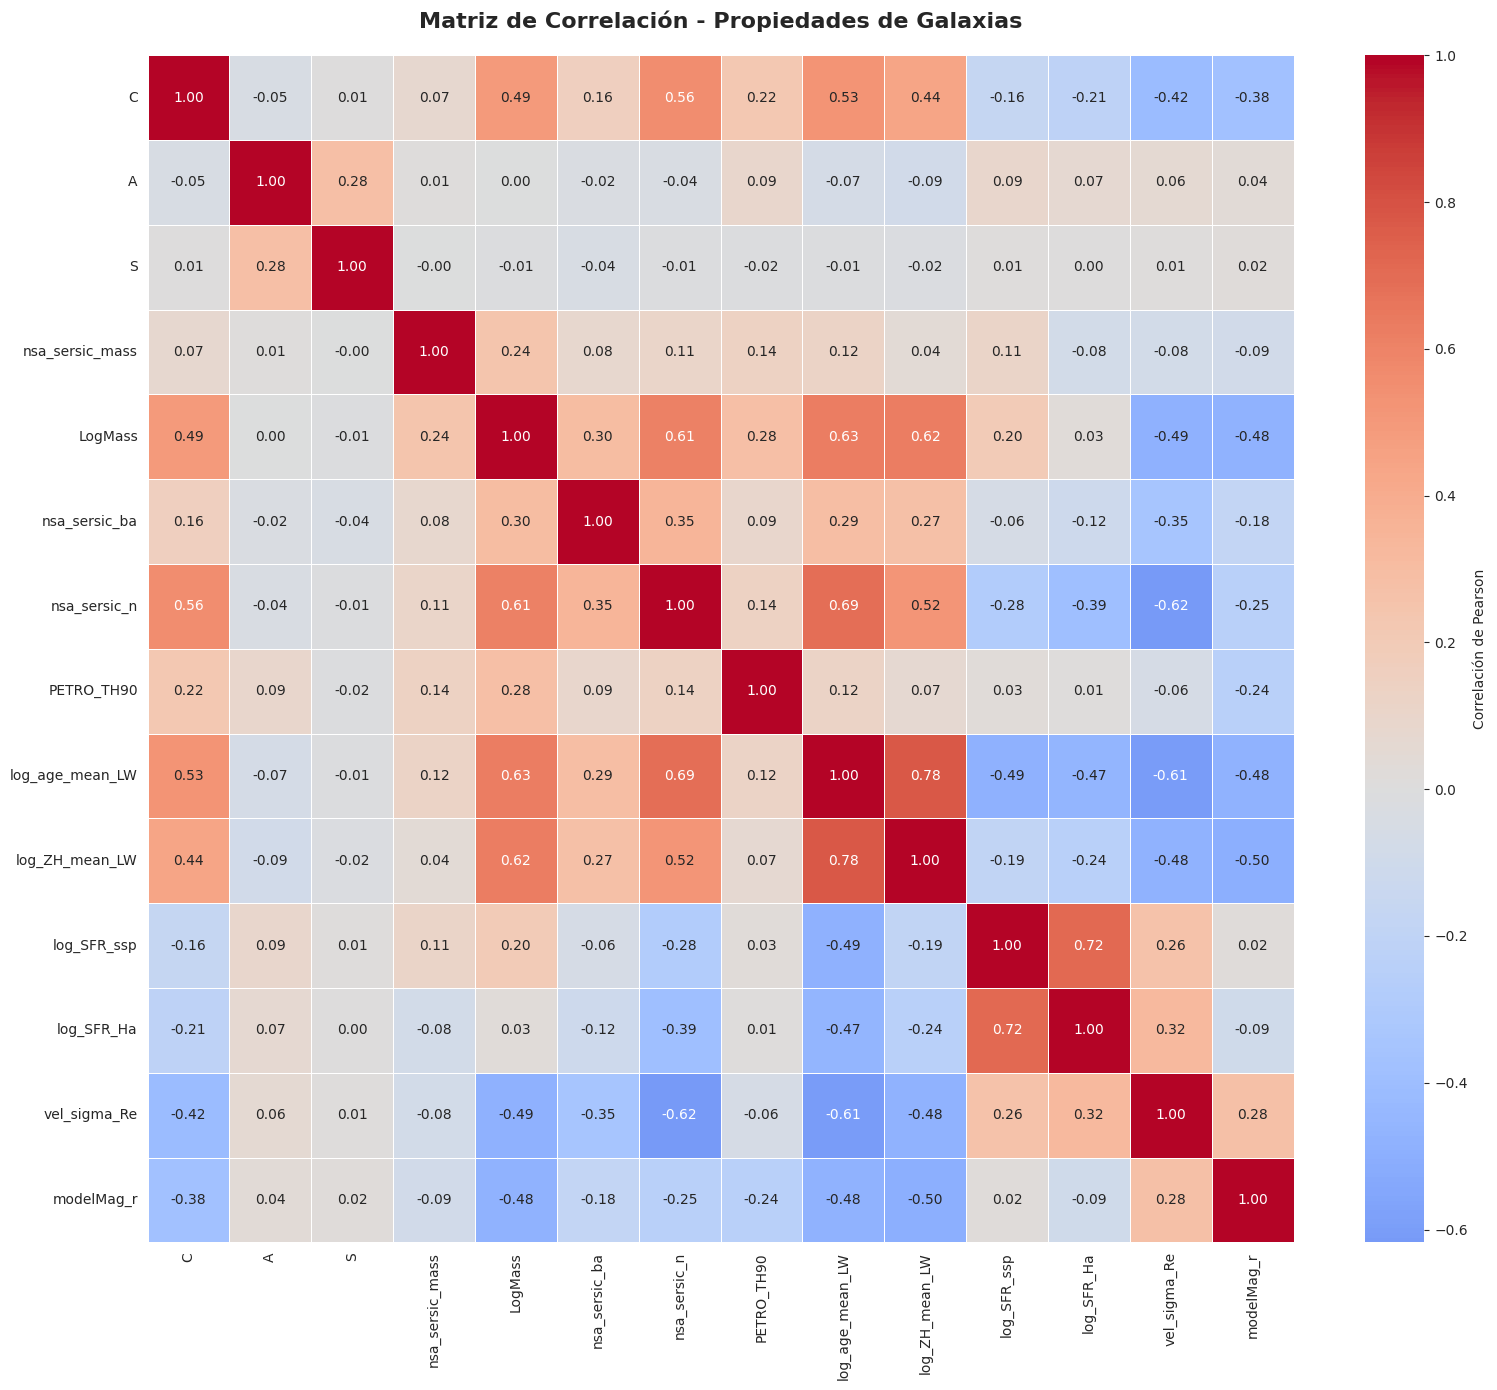


Interpretación de Correlación de Pearson:
  - Correlación = +1: Relación lineal positiva perfecta
  - Correlación = 0: Sin relación lineal
  - Correlación = -1: Relación lineal negativa perfecta
  - |Correlación| > 0.7: Correlación fuerte
  - |Correlación| > 0.5: Correlación moderada
  - |Correlación| < 0.3: Correlación débil


In [16]:
# Calcular matriz de correlación (excluyendo placeholders)
print("\nMATRIZ DE CORRELACIÓN DE PEARSON:\n")

# Crear una copia limpia del dataframe sin placeholders
df_clean = df.copy()
for col in numeric_cols:
    df_clean.loc[df_clean[col] < -100, col] = np.nan

# Seleccionar solo columnas numéricas para correlación (excluyendo coordenadas)
corr_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]
correlation_matrix = df_clean[corr_cols].corr()

# Visualizar matriz de correlación con heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de Correlación - Propiedades de Galaxias', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nInterpretación de Correlación de Pearson:")
print("  - Correlación = +1: Relación lineal positiva perfecta")
print("  - Correlación = 0: Sin relación lineal")
print("  - Correlación = -1: Relación lineal negativa perfecta")
print("  - |Correlación| > 0.7: Correlación fuerte")
print("  - |Correlación| > 0.5: Correlación moderada")
print("  - |Correlación| < 0.3: Correlación débil")

In [17]:
# Identificar pares de variables altamente correlacionadas
print("\nPARES DE VARIABLES CON ALTA CORRELACIÓN (|r| > 0.7):\n")

# Extraer pares con correlación alta
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Variable_1': correlation_matrix.columns[i],
                'Variable_2': correlation_matrix.columns[j],
                'Correlación': round(corr_value, 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlación', key=abs, ascending=False)

    print(high_corr_df.to_string(index=False))
    print("\n")
    print(f"\nTotal de pares con alta correlación: {len(high_corr_pairs)}")

    print("\nIMPLICACIONES:")
    print("  - Alta correlación puede indicar multicolinealidad")
    print("  - Considerar eliminar una de las variables del par para reducir redundancia")
    print("  - O aplicar técnicas de reducción de dimensionalidad (PCA, etc.)")
else:
    print("No se detectaron pares de variables con correlación > 0.7")
    print("Las variables son relativamente independientes entre sí.")


PARES DE VARIABLES CON ALTA CORRELACIÓN (|r| > 0.7):

     Variable_1     Variable_2  Correlación
log_age_mean_LW log_ZH_mean_LW        0.775
    log_SFR_ssp     log_SFR_Ha        0.716



Total de pares con alta correlación: 2

IMPLICACIONES:
  - Alta correlación puede indicar multicolinealidad
  - Considerar eliminar una de las variables del par para reducir redundancia
  - O aplicar técnicas de reducción de dimensionalidad (PCA, etc.)


## 8. Análisis de Distribución por Categorías  
### ¿Cómo se distribuyen los datos en función de diferentes categorías?

El análisis de distribución por categorías nos ayuda a:

- Comparar cómo cambia una variable numérica entre distintos grupos
- Identificar diferencias significativas entre categorías
- Detectar outliers o variabilidad dentro de cada grupo
- Comprender si una categoría influye en el comportamiento de otra variable
- Analizar patrones y tendencias entre variables categóricas y numéricas

In [18]:
# 8) Función reutilizable para análisis bivariado contra una variable objetivo


def bivariate_analysis(df, target_col="LogMass", max_plots=12):


    #
    # Variables seleccionadas del análisis
    #
    selected_columns = [

        # Variables de masa y estructura
        "nsa_sersic_mass",
        "LogMass",
        "nsa_sersic_ba",
        "nsa_sersic_n",
        "PETRO_TH90",

        # Variables de formación estelar y composición
        "log_age_mean_LW",
        "log_ZH_mean_LW",
        "log_SFR_ssp",
        "log_SFR_Ha",

        # Variables cinemáticas y fotométricas
        "vel_sigma_Re",
        "modelMag_r"
    ]

    #
    # Filtrar columnas existentes
    #
    selected_columns = [col for col in selected_columns if col in df.columns]

    # Crear dataframe numérico
    data = df[selected_columns].copy()

    # Eliminar filas con NaN en target
    data = data.dropna(subset=[target_col])

    #
    # MATRIZ DE CORRELACIÓN
    #
    corr_matrix = data.corr(numeric_only=True)


    #
    # CORRELACIÓN CON VARIABLE OBJETIVO
    #
    correlations = corr_matrix[target_col].sort_values(
        ascending=False
    )

    print(f"\nCorrelación con '{target_col}':\n")
    print(correlations)

    #
    # SCATTER PLOTS
    #
    features = [
        col for col in selected_columns
        if col != target_col
    ]

    features = features[:max_plots]

    n_cols = 3
    n_rows = int(np.ceil(len(features) / n_cols))

    plt.figure(figsize=(18, 5 * n_rows))

    for i, feature in enumerate(features, 1):

        plt.subplot(n_rows, n_cols, i)

        sns.regplot(
            data=data,
            x=feature,
            y=target_col,
            scatter_kws={
                "alpha": 0.4,
                "s": 15
            },
            line_kws={
                "color": "red"
            }
        )

        plt.title(f"{feature} vs {target_col}")
        plt.xlabel(feature)
        plt.ylabel(target_col)

    plt.tight_layout()
    plt.show()


Correlación con 'LogMass':

LogMass            1.0000
log_age_mean_LW    0.6258
log_ZH_mean_LW     0.6237
nsa_sersic_n       0.6106
nsa_sersic_ba      0.2997
PETRO_TH90         0.2832
nsa_sersic_mass    0.2425
log_SFR_ssp        0.2016
log_SFR_Ha         0.0291
modelMag_r        -0.4816
vel_sigma_Re      -0.4856
Name: LogMass, dtype: float64


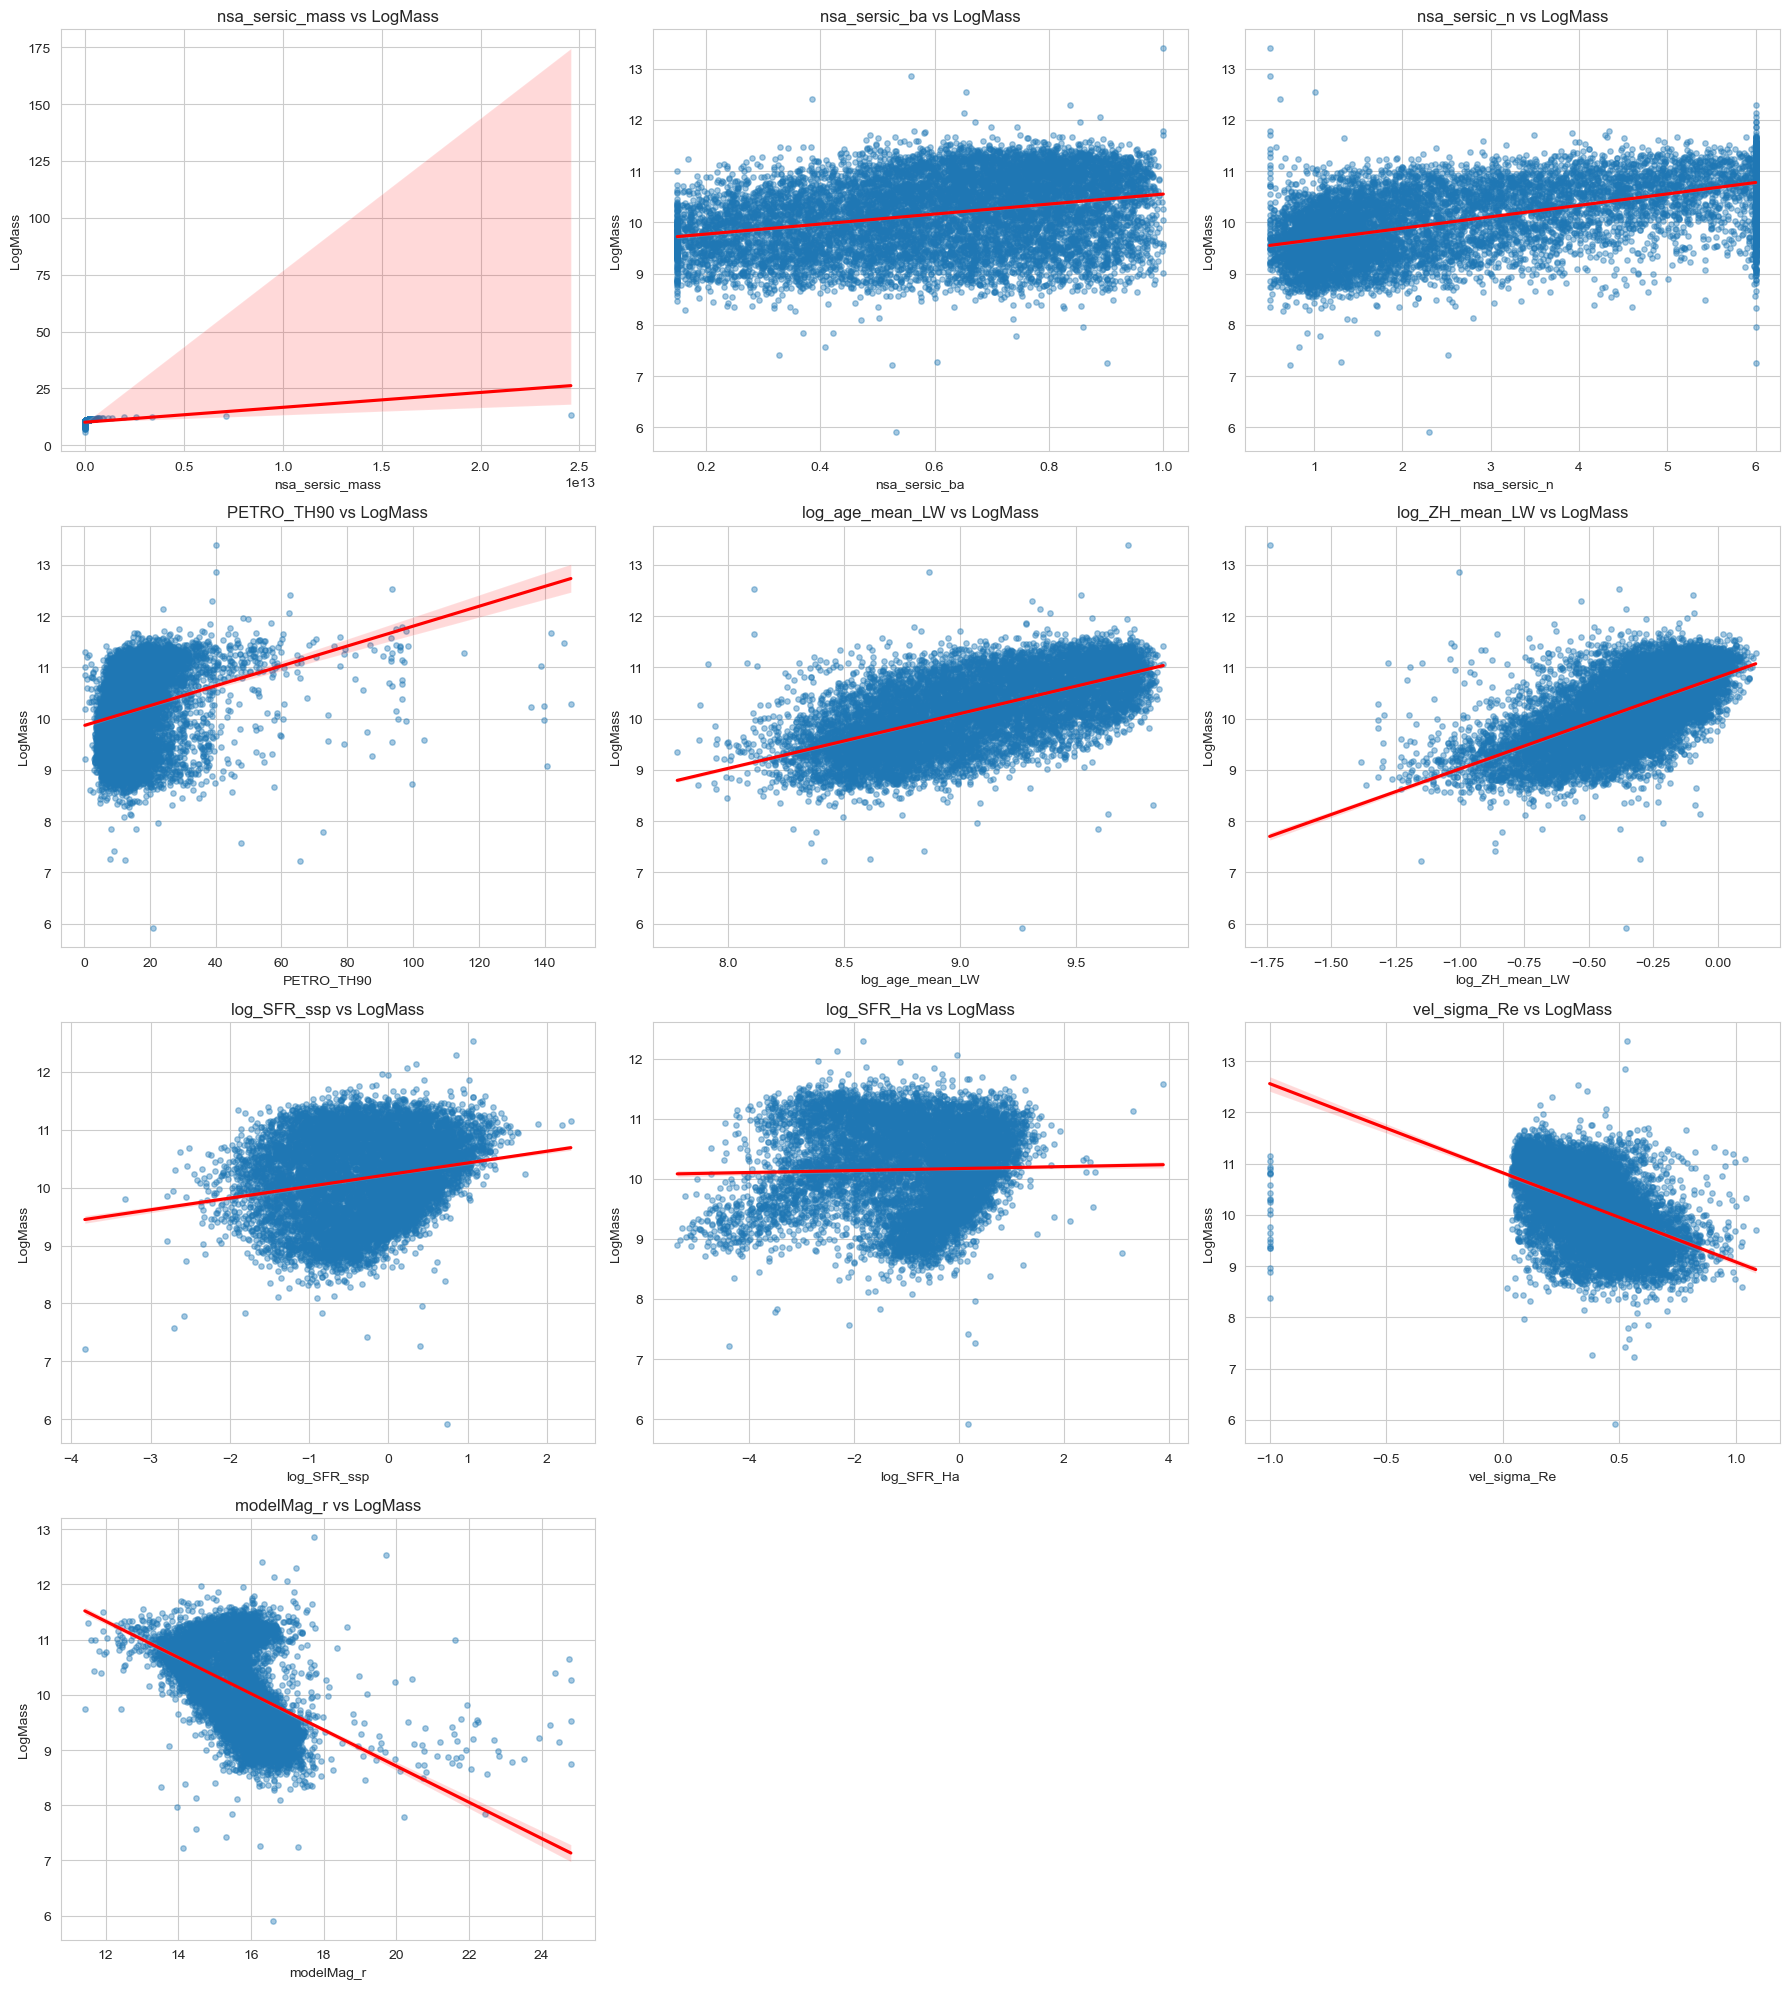

In [ ]:
bivariate_analysis(df, "LogMass")


Correlación con 'log_age_mean_LW':

log_age_mean_LW    1.0000
log_ZH_mean_LW     0.7754
nsa_sersic_n       0.6859
LogMass            0.6258
nsa_sersic_ba      0.2877
PETRO_TH90         0.1244
nsa_sersic_mass    0.1240
log_SFR_Ha        -0.4652
modelMag_r        -0.4790
log_SFR_ssp       -0.4896
vel_sigma_Re      -0.6094
Name: log_age_mean_LW, dtype: float64


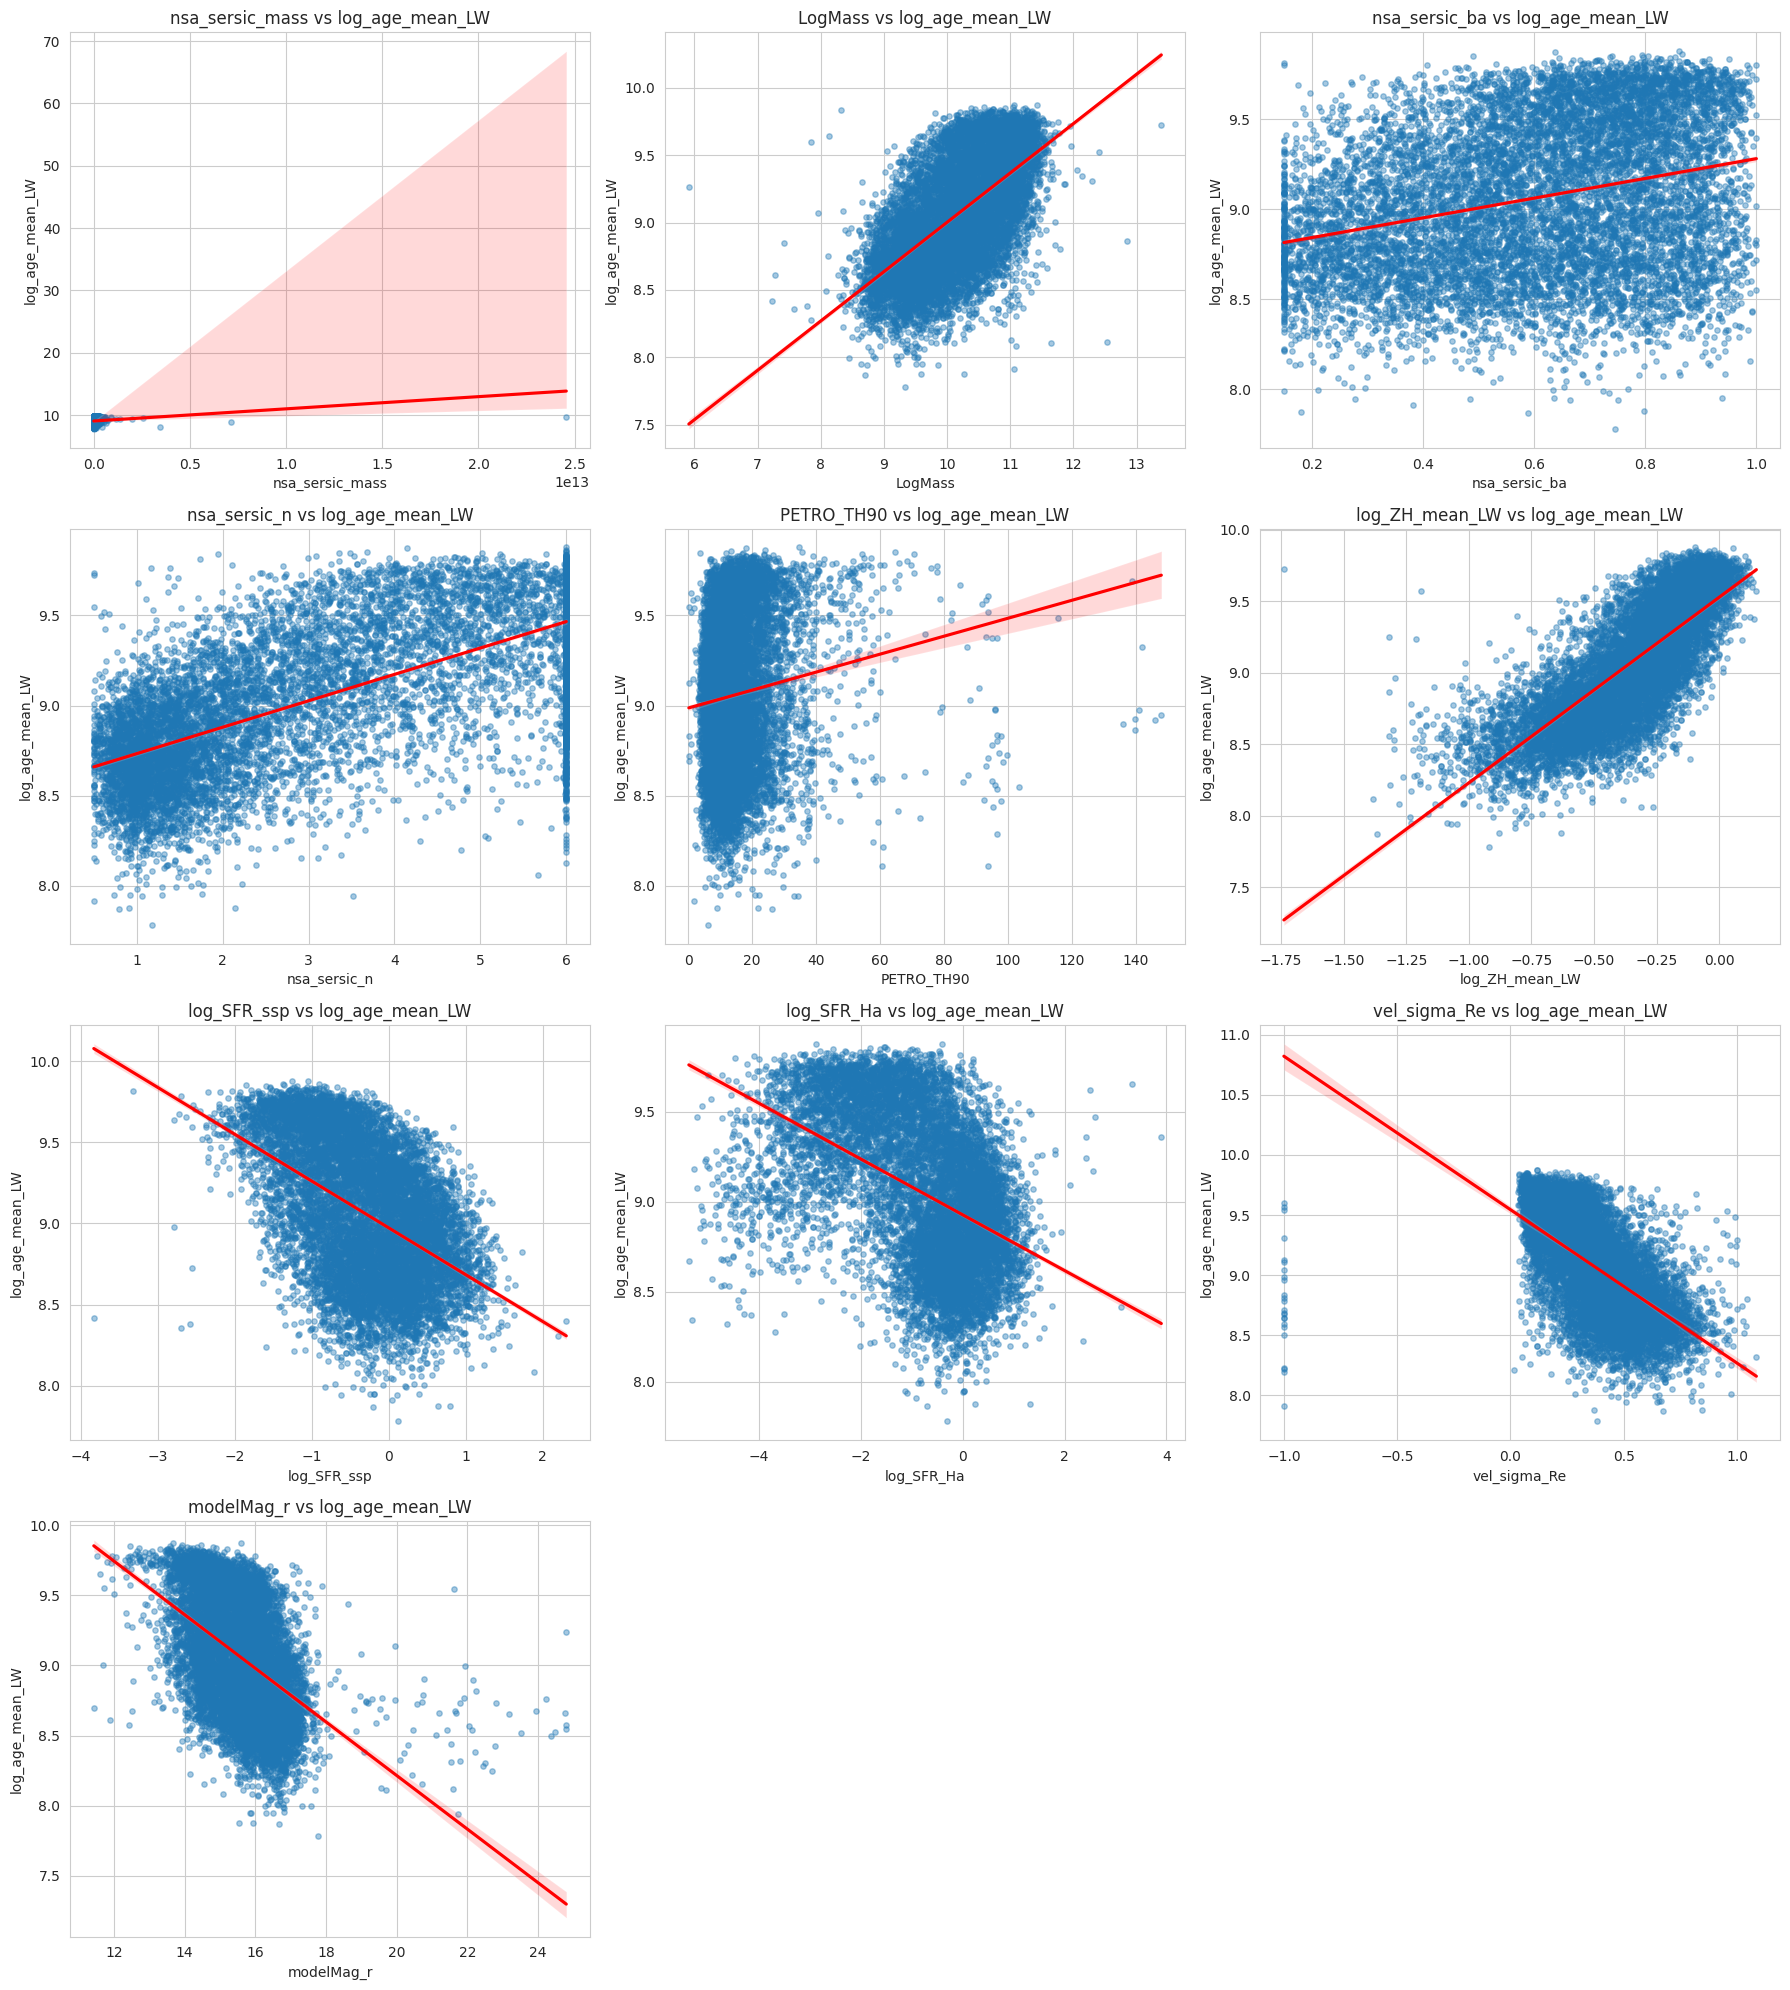

In [19]:
bivariate_analysis(df, "log_age_mean_LW")


Correlación con 'log_SFR_ssp':

log_SFR_ssp        1.0000
log_SFR_Ha         0.7157
vel_sigma_Re       0.2605
LogMass            0.2016
nsa_sersic_mass    0.1126
PETRO_TH90         0.0308
modelMag_r         0.0199
nsa_sersic_ba     -0.0579
log_ZH_mean_LW    -0.1936
nsa_sersic_n      -0.2765
log_age_mean_LW   -0.4896
Name: log_SFR_ssp, dtype: float64


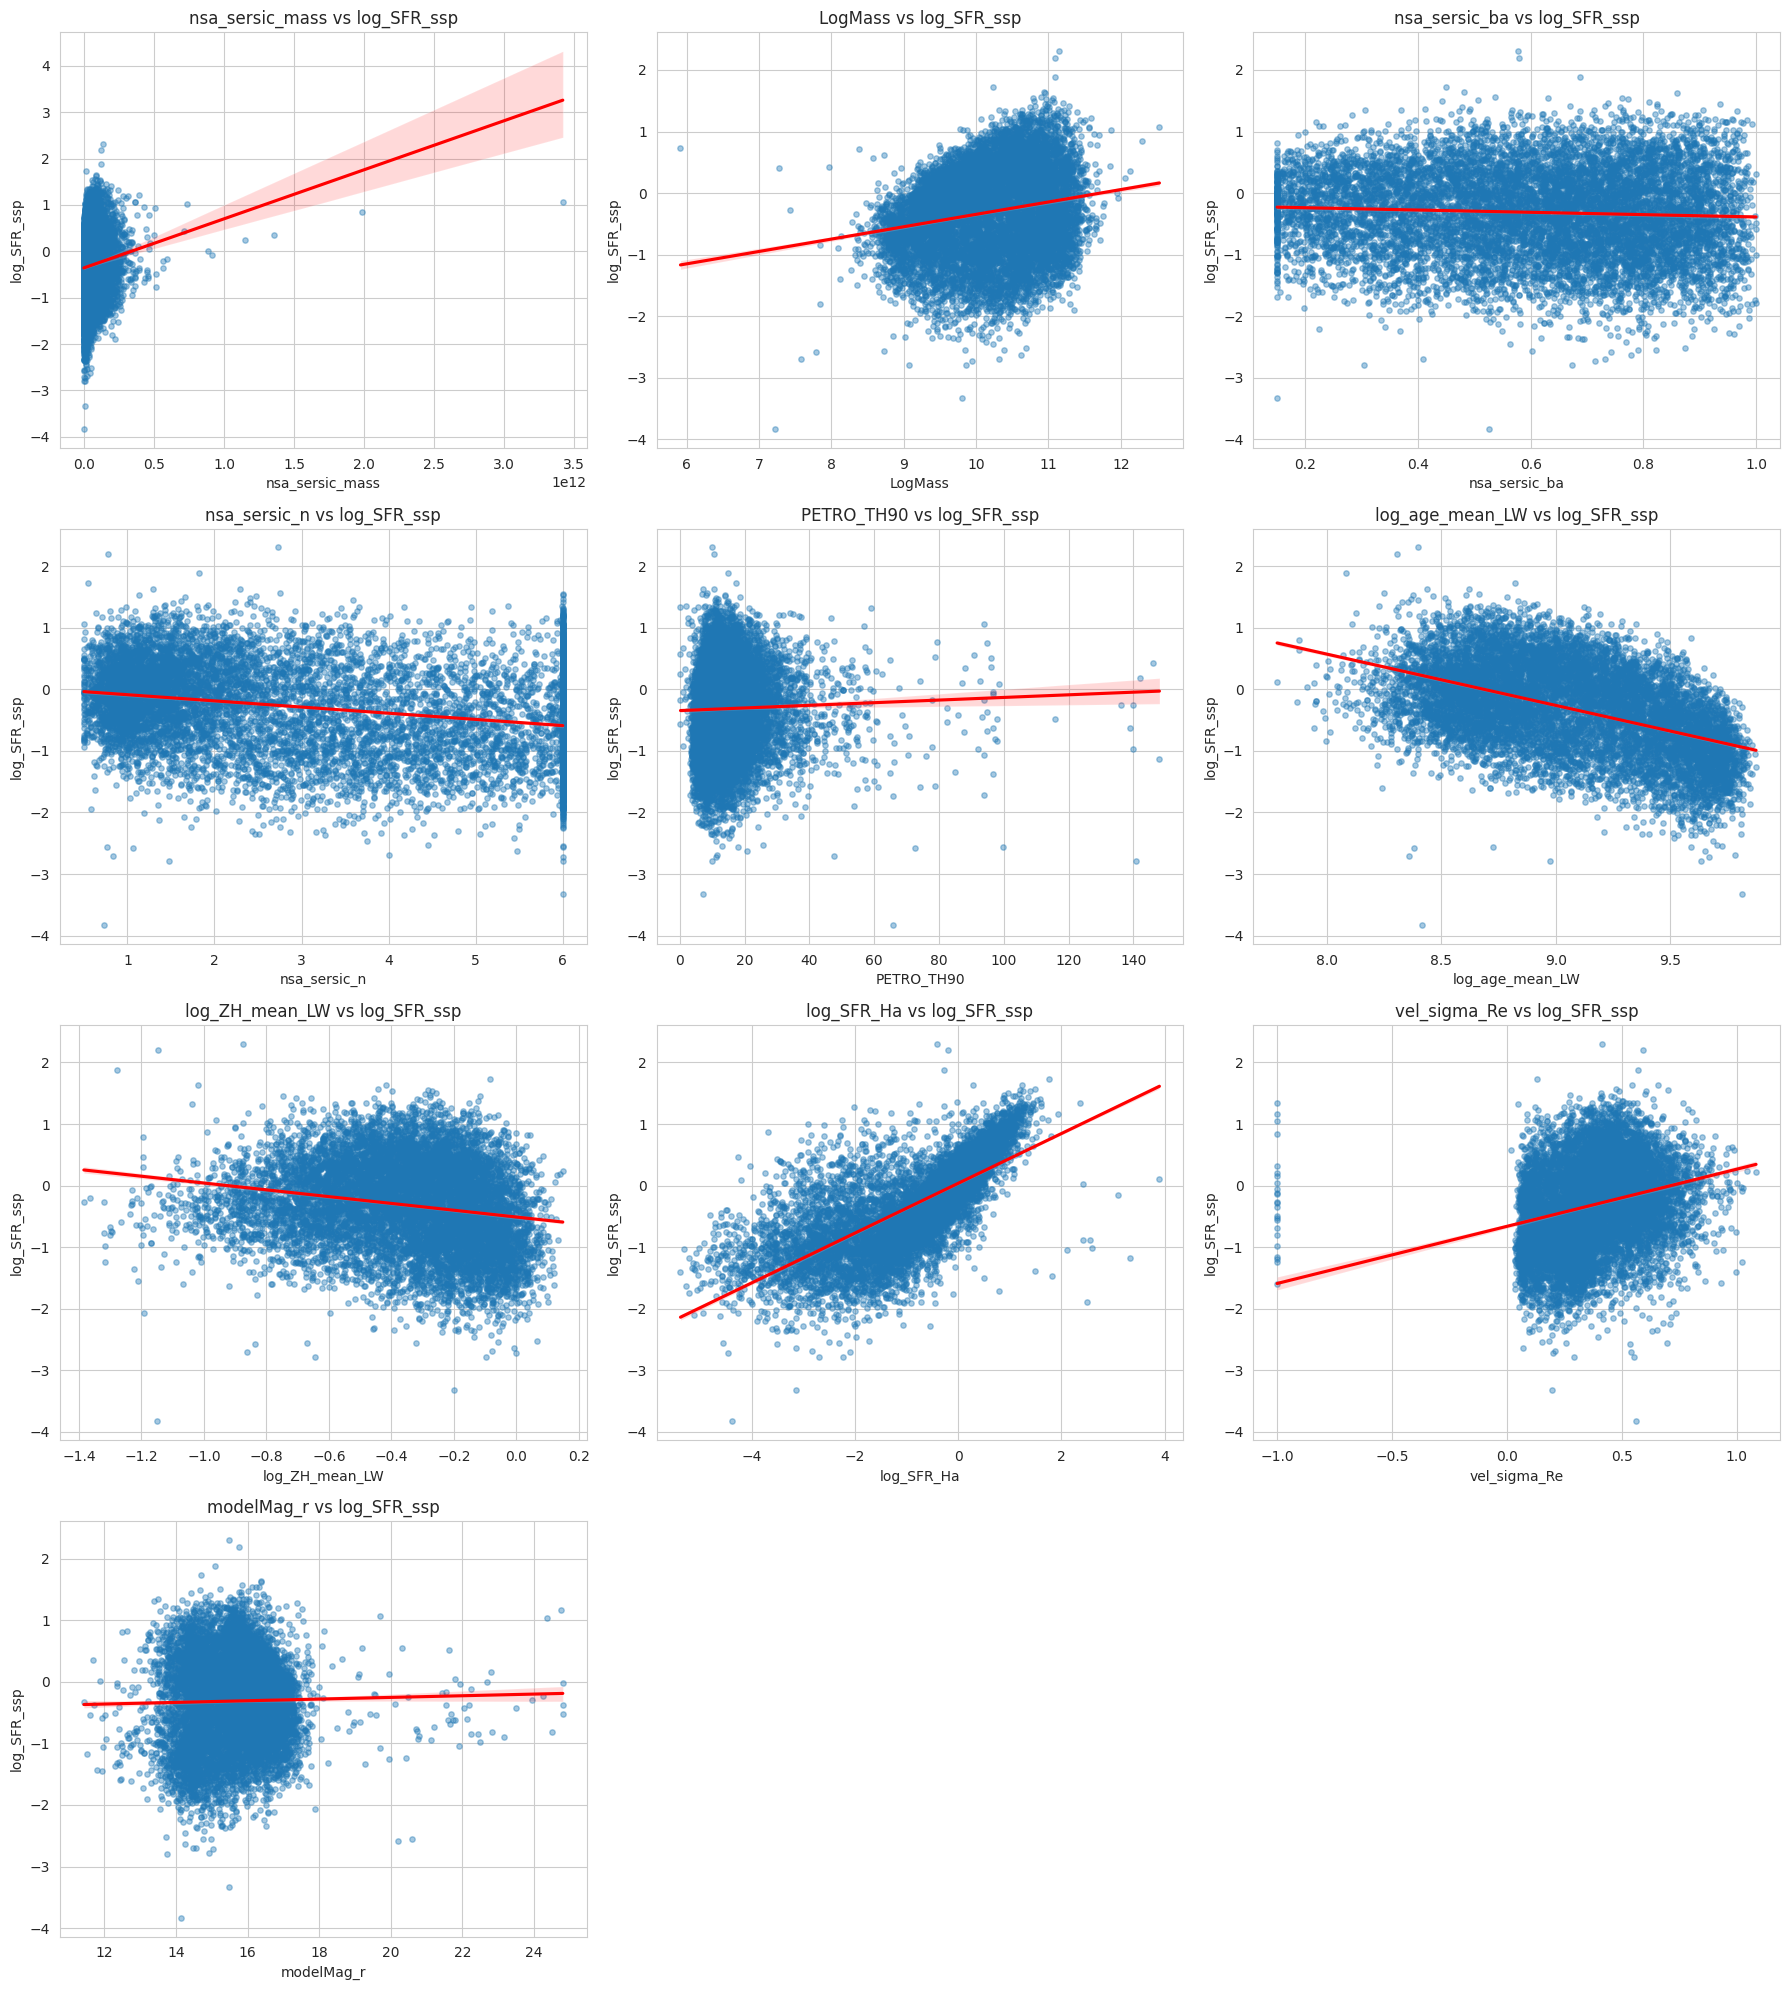

In [20]:
bivariate_analysis(df, "log_SFR_ssp")

## Justificación de Transformaciones

### 1. Limpieza de valores placeholder

Antes de aplicar cualquier transformación, se reemplazaron valores centinela o placeholders por NaN para tratarlos correctamente como datos faltantes.

Valores detectados:
- -999
- -9999
- -102.97
- -118.68

Justificación:
Estos valores no representan mediciones físicas reales y generan distorsiones severas en:
- medias,
- desviaciones estándar,
- asimetría,
- curtosis,
- detección de outliers.

---

## 2. Imputación de valores faltantes

Transformación aplicada:
- SimpleImputer(strategy="median")

Variables afectadas:
- log_SFR_Ha
- log_SFR_ssp
- vel_sigma_Re
- log_age_mean_LW
- log_ZH_mean_LW
- PETRO_TH90
- LogMass
- modelMag_r
- nsa_sersic_mass
- nsa_sersic_ba
- nsa_sersic_n

Justificación:
El porcentaje de valores faltantes es bajo (< 2%), por lo que la imputación mediante mediana:
- preserva la distribución original,
- reduce sensibilidad a outliers,
- evita pérdida innecesaria de observaciones.

---

## 3. Transformación Yeo-Johnson para variables sesgadas

Variables transformadas:
- nsa_sersic_mass
- PETRO_TH90
- modelMag_r
- C
- A
- S

Transformación aplicada:
- PowerTransformer(method="yeo-johnson")

Justificación:
Estas variables presentan asimetría fuerte y distribuciones no gaussianas.

La transformación Yeo-Johnson:
- reduce asimetría,
- estabiliza la varianza,
- aproxima distribuciones normales,
- mejora el desempeño de modelos sensibles a escala y distribución,
- y puede manejar valores negativos y cero sin requerir reflexión manual.

Esto es especialmente útil en variables morfológicas como:
- concentración (C),
- asimetría (A),
- suavidad (S),

que contienen valores negativos y distribuciones altamente sesgadas.

---

## 4. Estandarización de variables numéricas

Transformación aplicada:
- StandardScaler

Variables:
- LogMass
- nsa_sersic_ba
- nsa_sersic_n
- log_age_mean_LW
- log_ZH_mean_LW
- log_SFR_ssp
- log_SFR_Ha
- vel_sigma_Re
- objra
- objdec

Justificación:
Estas variables ya presentan distribuciones relativamente estables o se encuentran previamente transformadas en escala logarítmica.

La estandarización:
- centra las variables en media 0,
- ajusta desviación estándar a 1,
- evita dominancia de variables con escalas grandes,
- mejora convergencia de algoritmos de machine learning.

---

## 5. Tratamiento de coordenadas astronómicas

Variables:
- objra
- objdec

Transformación aplicada:
- StandardScaler

Justificación:
Las coordenadas astronómicas no requieren transformaciones de distribución, pero sí normalización para:
- mantener consistencia numérica,
- evitar diferencias de escala,
- facilitar algoritmos basados en distancia.

---

## 6. Beneficios generales del preprocesamiento

El pipeline de transformación permite:

- reducir el impacto de outliers,
- corregir distribuciones altamente sesgadas,
- manejar datos faltantes de forma robusta,
- estabilizar escalas numéricas,
- preparar el dataset para modelos estadísticos y de machine learning.

Además, el uso de ColumnTransformer garantiza:
- reproducibilidad,
- modularidad,
- integración sencilla con pipelines de entrenamiento y validación.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer

#
# 1. COPIA DEL DATASET
#

df_clean = df.copy()

#
# 2. REEMPLAZAR PLACEHOLDERS POR NaN
#

placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    df_clean[col] = df_clean[col].replace(values, np.nan)

#
# 3. DEFINICIÓN DE VARIABLES
#

# Variables con asimetría fuerte o potencialmente problemáticas
skewed_cols = [
    "nsa_sersic_mass",
    "PETRO_TH90",
    "modelMag_r",
    "C",
    "A",
    "S"
]

# Variables que ya están bastante estabilizadas o en log
normal_cols = [
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re"
]

# Coordenadas
coordinate_cols = [
    "objra",
    "objdec"
]

# Filtrar solo columnas existentes
skewed_cols = [c for c in skewed_cols if c in df_clean.columns]
normal_cols = [c for c in normal_cols if c in df_clean.columns]
coordinate_cols = [c for c in coordinate_cols if c in df_clean.columns]

#
# 4. PIPELINES
#

# Para variables sesgadas: imputación + Yeo-Johnson + escalado
skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# Para variables ya estables: imputación + escalado
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para coordenadas: imputación + escalado
coordinate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#
# 5. COLUMN TRANSFORMER
#

preprocessor = ColumnTransformer([
    ("skewed_vars", skewed_pipeline, skewed_cols),
    ("normal_vars", normal_pipeline, normal_cols),
    ("coordinates", coordinate_pipeline, coordinate_cols)
], remainder="drop")

#
# 6. AJUSTAR Y TRANSFORMAR
#

X_transformed = preprocessor.fit_transform(df_clean)

final_columns = skewed_cols + normal_cols + coordinate_cols

df_transformed = pd.DataFrame(X_transformed, columns=final_columns)

print("Shape original:", df_clean.shape)
print("Shape transformado:", df_transformed.shape)
print(df_transformed.head())

Shape original: (10126, 17)
Shape transformado: (10126, 16)
   nsa_sersic_mass  PETRO_TH90  modelMag_r       C       A       S  LogMass  \
0          -0.9490     -0.9719      0.8076 -1.3471 -0.0074 -0.0309  -0.9403   
1          -0.6325      0.1545      1.0683 -0.6744 -0.3508 -0.2956  -0.6049   
2          -0.0753     -0.0049      0.1766 -0.0944 -0.2080  0.1655  -0.0354   
3          -0.7591      1.4307     -0.8335  0.1224  0.0694  0.7020  -0.7380   
4          -0.1074     -0.3170      0.1993 -0.6729 -0.1478 -0.1510  -0.0674   

   nsa_sersic_ba  nsa_sersic_n  log_age_mean_LW  log_ZH_mean_LW  log_SFR_ssp  \
0        -1.2084       -1.2748          -1.1521         -1.3084       0.8322   
1        -0.4241       -0.9179          -1.0850         -0.7010       0.5290   
2        -1.7963       -0.5420          -0.7376         -0.1556       0.7577   
3        -2.0492       -1.2099          -0.7461         -0.7883      -0.0408   
4        -0.5909       -1.0158          -1.1710         -1.2657  

In [ ]:
# Vista previa de las primeras 10 filas del dataset
print("\nVISTA PREVIA DEL DATASET  ORIGINA(primeras 10 galaxias):\n")
df.head(10)


VISTA PREVIA DEL DATASET  ORIGINA(primeras 10 galaxias):



,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,133.3711,57.5984,2.419,0.191,0.26,3.0680e+09,9.4869,0.3353,0.7418,7.8809,8.5793,-0.6862,0.2797,-0.0895,0.7871,16.3824
1,manga-10001-12702,133.6857,57.4803,2.882,0.094,0.01,5.3416e+09,9.7277,0.5082,1.4427,14.1474,8.6074,-0.5342,0.0641,-0.6085,0.7881,16.6850
2,manga-10001-12703,136.0172,57.0923,3.249,0.135,0.43,1.3694e+10,10.1365,0.2057,2.1808,13.0018,8.7531,-0.3977,0.2267,0.1004,0.5039,15.6903
3,manga-10001-12704,133.9900,57.6780,3.380,0.212,0.85,4.2866e+09,9.6321,0.1500,0.8693,28.6829,8.7495,-0.5560,-0.3412,-0.4651,0.5194,14.6878
4,manga-10001-12705,136.7514,57.4514,2.883,0.152,0.15,1.2987e+10,10.1135,0.4715,1.2505,11.0396,8.5714,-0.6755,0.4678,0.4825,0.7696,15.7142
5,manga-10001-1901,133.3300,57.0412,2.709,0.140,0.18,1.3402e+09,9.1272,0.3335,0.7154,4.8629,9.0767,-0.2459,-0.8371,-0.8922,0.4456,17.2005
6,manga-10001-1902,134.1939,56.7867,3.964,0.100,-0.01,1.4535e+10,10.1624,0.7335,4.9523,12.3410,9.7670,-0.0747,-1.8509,-2.7075,0.1395,14.8354
7,manga-10001-3701,132.4656,57.1437,2.853,0.050,0.27,6.8655e+09,9.8367,0.6714,5.9563,4.5232,9.1803,-0.4393,-1.1397,-3.2127,0.1431,16.6792
8,manga-10001-3702,132.9128,57.1074,4.310,0.112,0.26,6.8592e+09,9.8363,0.8963,6.0000,13.0707,9.3457,-0.1532,-0.1689,-0.0564,0.1542,15.3195
9,manga-10001-3703,134.5915,57.6850,2.953,0.066,0.17,3.7466e+09,9.5736,0.3783,1.8669,5.5400,8.6239,-0.5629,0.0037,-0.1746,0.7017,16.7082


In [22]:
# Vista previa de las primeras 10 filas del dataset
print("\nVISTA PREVIA DEL DATASET CON TRANSFORMACIONES(primeras 10 galaxias):\n")
df_transformed.head(10)


VISTA PREVIA DEL DATASET CON TRANSFORMACIONES(primeras 10 galaxias):



,nsa_sersic_mass,PETRO_TH90,modelMag_r,C,A,S,LogMass,nsa_sersic_ba,nsa_sersic_n,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,objra,objdec
0,-0.9490,-0.9719,0.8076,-1.3471,-0.0074,-0.0309,-0.9403,-1.2084,-1.2748,-1.1521,-1.3084,0.8322,0.6072,2.0522,-0.6523,1.6126
1,-0.6325,0.1545,1.0683,-0.6744,-0.3508,-0.2956,-0.6049,-0.4241,-0.9179,-1.0850,-0.7010,0.5290,0.1930,2.0572,-0.6482,1.6060
2,-0.0753,-0.0049,0.1766,-0.0944,-0.2080,0.1655,-0.0354,-1.7963,-0.5420,-0.7376,-0.1556,0.7577,0.7587,0.6348,-0.6176,1.5844
3,-0.7591,1.4307,-0.8335,0.1224,0.0694,0.7020,-0.7380,-2.0492,-1.2099,-0.7461,-0.7883,-0.0408,0.3075,0.7127,-0.6442,1.6170
4,-0.1074,-0.3170,0.1993,-0.6729,-0.1478,-0.1510,-0.0674,-0.5909,-1.0158,-1.1710,-1.2657,1.0966,1.0637,1.9645,-0.6080,1.6044
5,-1.4063,-1.9243,1.4931,-0.9336,-0.1903,-0.1188,-1.4414,-1.2169,-1.2882,0.0340,0.4511,-0.7381,-0.0333,0.3433,-0.6528,1.5815
6,-0.0392,-0.1039,-0.6769,1.1510,-0.3301,-0.3155,0.0007,0.5979,0.8692,1.6802,1.1354,-2.1634,-1.4819,-1.1887,-0.6415,1.5674
7,-0.4864,-2.0670,1.0635,-0.7185,-0.5003,-0.0197,-0.4530,0.3161,1.3804,0.2810,-0.3217,-1.1635,-1.8851,-1.1708,-0.6641,1.5872
8,-0.4870,0.0051,-0.1828,1.8072,-0.2885,-0.0309,-0.4536,1.3363,1.4027,0.6755,0.8218,0.2014,0.6336,-1.1152,-0.6583,1.5852
9,-0.8359,-1.6668,1.0880,-0.5654,-0.4464,-0.1296,-0.8194,-1.0135,-0.7019,-1.0457,-0.8156,0.4441,0.5393,1.6250,-0.6363,1.6174


# Normalización de las imagenes
### ¿Se deberían normalizar las imágenes para visualizarlas mejor?

Aunque el presente análisis exploratorio se realizó principalmente sobre variables tabulares derivadas de observaciones astronómicas, el proyecto se encuentra relacionado con imágenes astronómicas. En este contexto, la normalización de imágenes constituye una etapa importante dentro del preprocesamiento de datos astronómicos.

Las imágenes astronómicas suelen presentar amplios rangos dinámicos de intensidad debido a diferencias de brillo entre objetos celestes, ruido instrumental y variaciones en las condiciones de observación. Por esta razón, técnicas de normalización y escalamiento permiten mejorar la visualización de estructuras relevantes, así como facilitar el entrenamiento de modelos de aprendizaje automático.

En etapas posteriores del proyecto, cuando se trabaje directamente con imágenes astronómicas, será necesario evaluar qué técnica de normalización preserva mejor la información física relevante sin introducir distorsiones artificiales en los datos.

# Conclusiones

El análisis exploratorio de datos permitió comprender las principales características estadísticas y estructurales del conjunto de datos astronómico utilizado para la inferencia de propiedades físicas de galaxias. A través de técnicas de análisis univariante y multivariante fue posible identificar patrones relevantes, relaciones entre variables y problemas de calidad de datos que deben atenderse antes del entrenamiento de modelos de aprendizaje automático.

### Calidad y estructura de los datos
En la etapa inicial se observó que el dataset contiene variables numéricas relacionadas con propiedades físicas, espectrales y fotométricas de galaxias, además de atributos derivados de observaciones astronómicas. El análisis descriptivo permitió identificar valores faltantes en 11 columnas del conjunto de datos, siendo `log_SFR_Ha` la variable con mayor porcentaje de ausencia con un 1.60%, seguida de `log_SFR_ssp`, `vel_sigma_Re`, `log_age_mean_LW` y `log_ZH_mean_LW`. En términos generales, el porcentaje de datos faltantes resultó relativamente bajo, lo que sugiere una buena calidad global del dataset y permite aplicar estrategias de imputación sin comprometer significativamente la representatividad de los datos.

Asimismo, se detectó la presencia de valores *placeholder* o centinela utilizados para representar mediciones inválidas o no disponibles. Entre los principales valores identificados se encontraron `-999` y `-9999`, presentes en variables como `C`, `A`, `S`, `nsa_sersic_mass` y `nsa_sersic_ba`. Además, algunas columnas contenían valores extremadamente negativos que podrían corresponder a registros erróneos o datos físicamente inconsistentes.

### Distribución y comportamiento estadístico de las variables
El análisis de distribuciones reveló que varias variables presentan asimetrías significativas y colas largas, evidenciando desviaciones importantes respecto a distribuciones normales. Variables como `nsa_sersic_mass` mostraron una asimetría positiva extrema (`79.498`), mientras que variables como `S` y `A` presentaron asimetrías negativas pronunciadas (`-26.974` y `-22.66`, respectivamente), asociadas principalmente a la presencia de valores atípicos y *placeholders*. De igual manera, `PETRO_TH90` presentó una asimetría positiva considerable (`4.03`), indicando una distribución con cola derecha larga. En contraste, variables como `LogMass`, `log_age_mean_LW` y `log_SFR_ssp` presentaron distribuciones más cercanas a una forma aproximadamente normal. Asimismo, la diferencia observada entre media y mediana en múltiples variables confirmó la presencia de sesgos y valores extremos dentro del conjunto de datos.

A partir de estos resultados se identificó la necesidad de aplicar transformaciones estadísticas específicas para reducir la asimetría y mejorar la estabilidad numérica de los datos. Entre las estrategias consideradas destacan transformaciones logarítmicas, Box-Cox y transformaciones por reflexión para variables con colas negativas pronunciadas. Estos hallazgos evidenciaron la necesidad de aplicar estrategias de limpieza, imputación, transformación estadística y escalamiento antes de utilizar los datos en modelos de aprendizaje automático.

### Preprocesamiento y tratamiento de valores atípicos
Respecto al preprocesamiento, los valores inválidos y *placeholders* identificados fueron reemplazados por valores nulos para posteriormente aplicar estrategias de imputación que permitieran preservar la consistencia y representatividad del conjunto de datos. Asimismo, mediante histogramas y diagramas de caja (*boxplots*), se detectó la presencia de valores atípicos y distintos niveles de dispersión entre variables. Algunas características, como `nsa_sersic_mass` y `PETRO_TH90`, presentaron colas extremas y una gran cantidad de observaciones fuera del rango intercuartílico, evidenciando distribuciones altamente sesgadas. De igual manera, variables como `A` y `S` mostraron valores atípicos negativos extremos, asociados tanto a distribuciones asimétricas como a la presencia de valores *placeholder* identificados previamente.

En contraste, variables como `log_age_mean_LW` y `nsa_sersic_ba` mostraron distribuciones más estables y concentradas alrededor de la mediana, reflejando un comportamiento estadístico menos disperso. Estas diferencias evidencian que las variables del dataset poseen características estadísticas heterogéneas, por lo que las estrategias de preprocesamiento no pueden aplicarse de manera uniforme sobre todas las columnas.

Debido a la naturaleza científica del problema, los valores atípicos no fueron eliminados automáticamente, ya que podrían corresponder a fenómenos astronómicos reales y no necesariamente a errores de medición. Para mitigar el impacto de distribuciones sesgadas y mejorar la estabilidad estadística del dataset, se consideraron estrategias de transformación y escalamiento, incluyendo transformaciones logarítmicas, métodos tipo Box-Cox y técnicas de normalización aplicadas sobre variables numéricas relevantes.

Durante el preprocesamiento se conservaron las variables numéricas relevantes para el análisis estadístico y modelado, mientras que atributos no numéricos como `name`, utilizados únicamente como identificadores, fueron excluidos del conjunto transformado. Esto permitió aplicar técnicas de imputación, transformación y escalamiento de manera consistente sobre las variables físicas y espectrales del dataset.

### Análisis multivariante y correlación entre variables
El análisis multivariante permitió identificar relaciones relevantes entre distintas variables físicas y espectrales del conjunto de datos. A través de matrices de correlación y visualizaciones gráficas fue posible detectar dependencias lineales entre múltiples atributos, así como posibles casos de redundancia y multicolinealidad.

En particular, se identificaron dos pares de variables con correlaciones elevadas (`|r| > 0.7`). El primer caso corresponde a `log_age_mean_LW` y `log_ZH_mean_LW`, con una correlación de `0.775`, lo cual sugiere una relación importante entre la edad promedio de las poblaciones estelares y su metalicidad. El segundo caso corresponde a `log_SFR_ssp` y `log_SFR_Ha`, con una correlación de `0.716`, indicando consistencia entre distintas métricas asociadas con la tasa de formación estelar de las galaxias.

Estas relaciones son coherentes con comportamientos esperados en astronomía, donde múltiples propiedades físicas de las galaxias se encuentran interconectadas debido a procesos evolutivos y dinámicas astrofísicas subyacentes. No obstante, la presencia de correlaciones elevadas también puede indicar redundancia parcial de información y posibles efectos de multicolinealidad entre variables, aspecto que deberá considerarse durante el desarrollo de modelos predictivos.

Aunque se identificaron pares de variables con alta correlación, no se realizó una eliminación automática de atributos basada únicamente en este criterio, ya que dichas relaciones podrían contener información físicamente relevante dentro del contexto astronómico. Sin embargo, en etapas posteriores del proyecto podrá evaluarse el uso de técnicas de selección de características o reducción de dimensionalidad, como PCA, con el objetivo de disminuir redundancia, mejorar la interpretabilidad y aumentar la capacidad de generalización de los modelos.

### Implicaciones para etapas posteriores del proyecto

Adicionalmente, aunque el problema corresponde a una tarea de regresión y no de clasificación, se analizaron las distribuciones de las variables objetivo para identificar posibles concentraciones de muestras en determinados rangos de valores. Los resultados mostraron distribuciones no uniformes y, en algunos casos, sesgadas, aspecto que deberá considerarse durante el entrenamiento y evaluación de los modelos para evitar sesgos hacia regiones con mayor densidad de observaciones.

En términos generales, el análisis exploratorio de datos permitió establecer una base sólida para las siguientes etapas del proyecto, facilitando la comprensión de la estructura del dataset, la identificación de variables relevantes y la detección de posibles limitaciones de los datos. Los hallazgos obtenidos servirán como fundamento para el desarrollo de modelos con mayor robustez, capacidad de generalización y mejor desempeño en la inferencia de propiedades físicas de galaxias dentro del contexto del análisis astronómico a gran escala.

---

---

---

# ACTIVIDAD 2: INGENIERÍA DE CARACTERÍSTICAS Y SELECCIÓN DE FEATURES

**Equipo 61**

## Objetivo

En esta fase de **Feature Engineering**, aplicaremos operaciones avanzadas para:
1. **Crear nuevas características** que capturen relaciones físicas importantes entre variables
2. **Aplicar transformaciones** para normalizar distribuciones y reducir sesgos
3. **Implementar técnicas de selección** para identificar las características más relevantes
4. **Reducir dimensionalidad** cuando sea apropiado para mejorar eficiencia

Todo esto con el fin de mejorar el rendimiento de los modelos de machine learning, mitigar el riesgo de características sesgadas y acelerar la convergencia de algoritmos.

---

In [23]:
# Importaciones adicionales para Feature Engineering
from sklearn.preprocessing import (
    PowerTransformer,      # Para transformaciones Yeo-Johnson y Box-Cox
    QuantileTransformer,   # Para transformación uniforme/normal
    KBinsDiscretizer       # Para discretización/binning
)
from sklearn.feature_selection import (
    VarianceThreshold,           # Filtro por varianza
    SelectKBest,                 # Selección de k mejores features
    f_regression,                # F-test para regresión (ANOVA)
    mutual_info_regression,      # Información mutua
    RFE                          # Recursive Feature Elimination
)
from sklearn.decomposition import PCA, FactorAnalysis  # Reducción de dimensionalidad
from sklearn.ensemble import RandomForestRegressor      # Para importancia de features
from sklearn.linear_model import LassoCV                # Para selección L1
from scipy.stats import chi2_contingency                # Test Chi-cuadrado
import itertools  # Para combinaciones de features

# Recargar datos procesados del Avance 1
print("Cargando datos procesados del Avance 1...")
df = pd.read_csv('inferencia.csv')

# Recrear el dataframe limpio (sin placeholders)
df_clean = df.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Reemplazar placeholders por NaN
for col in numeric_cols:
    df_clean.loc[df_clean[col] < -100, col] = np.nan

# Imputar valores faltantes con la mediana
for col in numeric_cols:
    if df_clean[col].isna().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

print(f"\n Datos cargados: {df_clean.shape[0]:,} galaxias × {df_clean.shape[1]} variables")
print(f"Variables numéricas: {len(numeric_cols)}")

Cargando datos procesados del Avance 1...

 Datos cargados: 10,126 galaxias × 17 variables
Variables numéricas: 16


---

## 1. GENERACIÓN DE NUEVAS CARACTERÍSTICAS

### Justificación

En astronomía, muchas relaciones físicas importantes no son capturadas directamente por variables individuales, sino por **combinaciones** o **interacciones** entre ellas. Por ejemplo:

- **Compactness**: La relación entre masa y tamaño revela qué tan compacta es una galaxia
- **Specific Star Formation Rate (sSFR)**: Tasa de formación estelar normalizada por masa
- **Color-Mass correlations**: Relaciones entre propiedades fotométricas y estructura

Crearemos features basadas en conocimiento del dominio astronómico y relaciones matemáticas que puedan mejorar el poder predictivo del modelo.

In [26]:
# Generación de nuevas características basadas en física de galaxias
print("GENERACIÓN DE NUEVAS CARACTERÍSTICAS (FEATURE ENGINEERING)\n\n")

df_engineered = df_clean.copy()

# 1. Specific Star Formation Rate (sSFR) - Tasa de formación estelar específica
# sSFR = SFR / Mass (indica qué tan activamente está formando estrellas relativo a su masa)
df_engineered['sSFR_Ha'] = df_engineered['log_SFR_Ha'] - df_engineered['LogMass']
df_engineered['sSFR_ssp'] = df_engineered['log_SFR_ssp'] - df_engineered['LogMass']
print(" sSFR (Specific Star Formation Rate) creado: log(SFR) - log(Mass)")

# 2. Compactness - Densidad superficial de masa (Mass / Size^2)
# Indica qué tan compacta es la distribución de masa en la galaxia
df_engineered['Compactness'] = df_engineered['LogMass'] - 2 * np.log10(df_engineered['PETRO_TH90'] + 1)
print(" Compactness creado: log(Mass) - 2*log(Size)")

# 3. Morphological Index - Combinación de parámetros CAS
# Índice morfológico que combina Concentración, Asimetría y Suavidad
df_engineered['Morphology_Index'] = df_engineered['C'] - df_engineered['A'] + df_engineered['S']
print(" Morphology Index creado: C - A + S")

# 4. Axis Ratio inverso (circularidad)
# ba cercano a 1 = circular, cercano a 0 = muy elíptica
df_engineered['Ellipticity'] = 1 - df_engineered['nsa_sersic_ba']
print(" Ellipticity creado: 1 - ba (axis ratio)")

# 5. Metallicity per Age - Enriquecimiento químico normalizado
df_engineered['Z_per_Age'] = df_engineered['log_ZH_mean_LW'] / df_engineered['log_age_mean_LW']
print(" Z_per_Age creado: Metalicidad / Edad")

# 6. Velocity Dispersion Proxy - Relación de Faber-Jackson
# sigma ~ M^(1/4) para galaxias elípticas
df_engineered['vel_sigma_norm'] = df_engineered['vel_sigma_Re'] / (df_engineered['LogMass'] ** 0.25)
print(" vel_sigma_norm creado: sigma / Mass^0.25 (Faber-Jackson)")

# 7. Central Surface Brightness Proxy
# Brillo superficial central estimado
df_engineered['Central_Brightness'] = df_engineered['modelMag_r'] - 2.5 * np.log10(np.pi * (df_engineered['PETRO_TH90'] + 1)**2)
print(" Central_Brightness creado: Mag - 2.5*log(π*Size^2)")

# 8. SFR Consistency - Diferencia entre dos métodos de medir SFR
df_engineered['SFR_Consistency'] = np.abs(df_engineered['log_SFR_Ha'] - df_engineered['log_SFR_ssp'])
print(" SFR_Consistency creado: |SFR_Ha - SFR_ssp|")

# 9. Mass-to-Light Ratio proxy
df_engineered['Mass_to_Light'] = df_engineered['LogMass'] + 0.4 * df_engineered['modelMag_r']
print(" Mass_to_Light creado: log(M) + 0.4*Mag")

# 10. Bulge-to-Total Ratio proxy (usando índice de Sersic)
# n alto = bulge dominante, n bajo = disco dominante
df_engineered['Bulge_Proxy'] = np.tanh(df_engineered['nsa_sersic_n'] / 4.0)  # Normalizado a [0,1]
print(" Bulge_Proxy creado: tanh(n/4) - proxy de Bulge/Total")

print("\n")
print(f"Total de nuevas características creadas: 10")
print(f"Dimensiones actuales: {df_engineered.shape[0]:,} × {df_engineered.shape[1]}")

GENERACIÓN DE NUEVAS CARACTERÍSTICAS (FEATURE ENGINEERING)


 sSFR (Specific Star Formation Rate) creado: log(SFR) - log(Mass)
 Compactness creado: log(Mass) - 2*log(Size)
 Morphology Index creado: C - A + S
 Ellipticity creado: 1 - ba (axis ratio)
 Z_per_Age creado: Metalicidad / Edad
 vel_sigma_norm creado: sigma / Mass^0.25 (Faber-Jackson)
 Central_Brightness creado: Mag - 2.5*log(π*Size^2)
 SFR_Consistency creado: |SFR_Ha - SFR_ssp|
 Mass_to_Light creado: log(M) + 0.4*Mag
 Bulge_Proxy creado: tanh(n/4) - proxy de Bulge/Total


Total de nuevas características creadas: 10
Dimensiones actuales: 10,126 × 28



 VISUALIZACIÓN DE NUEVAS CARACTERÍSTICAS



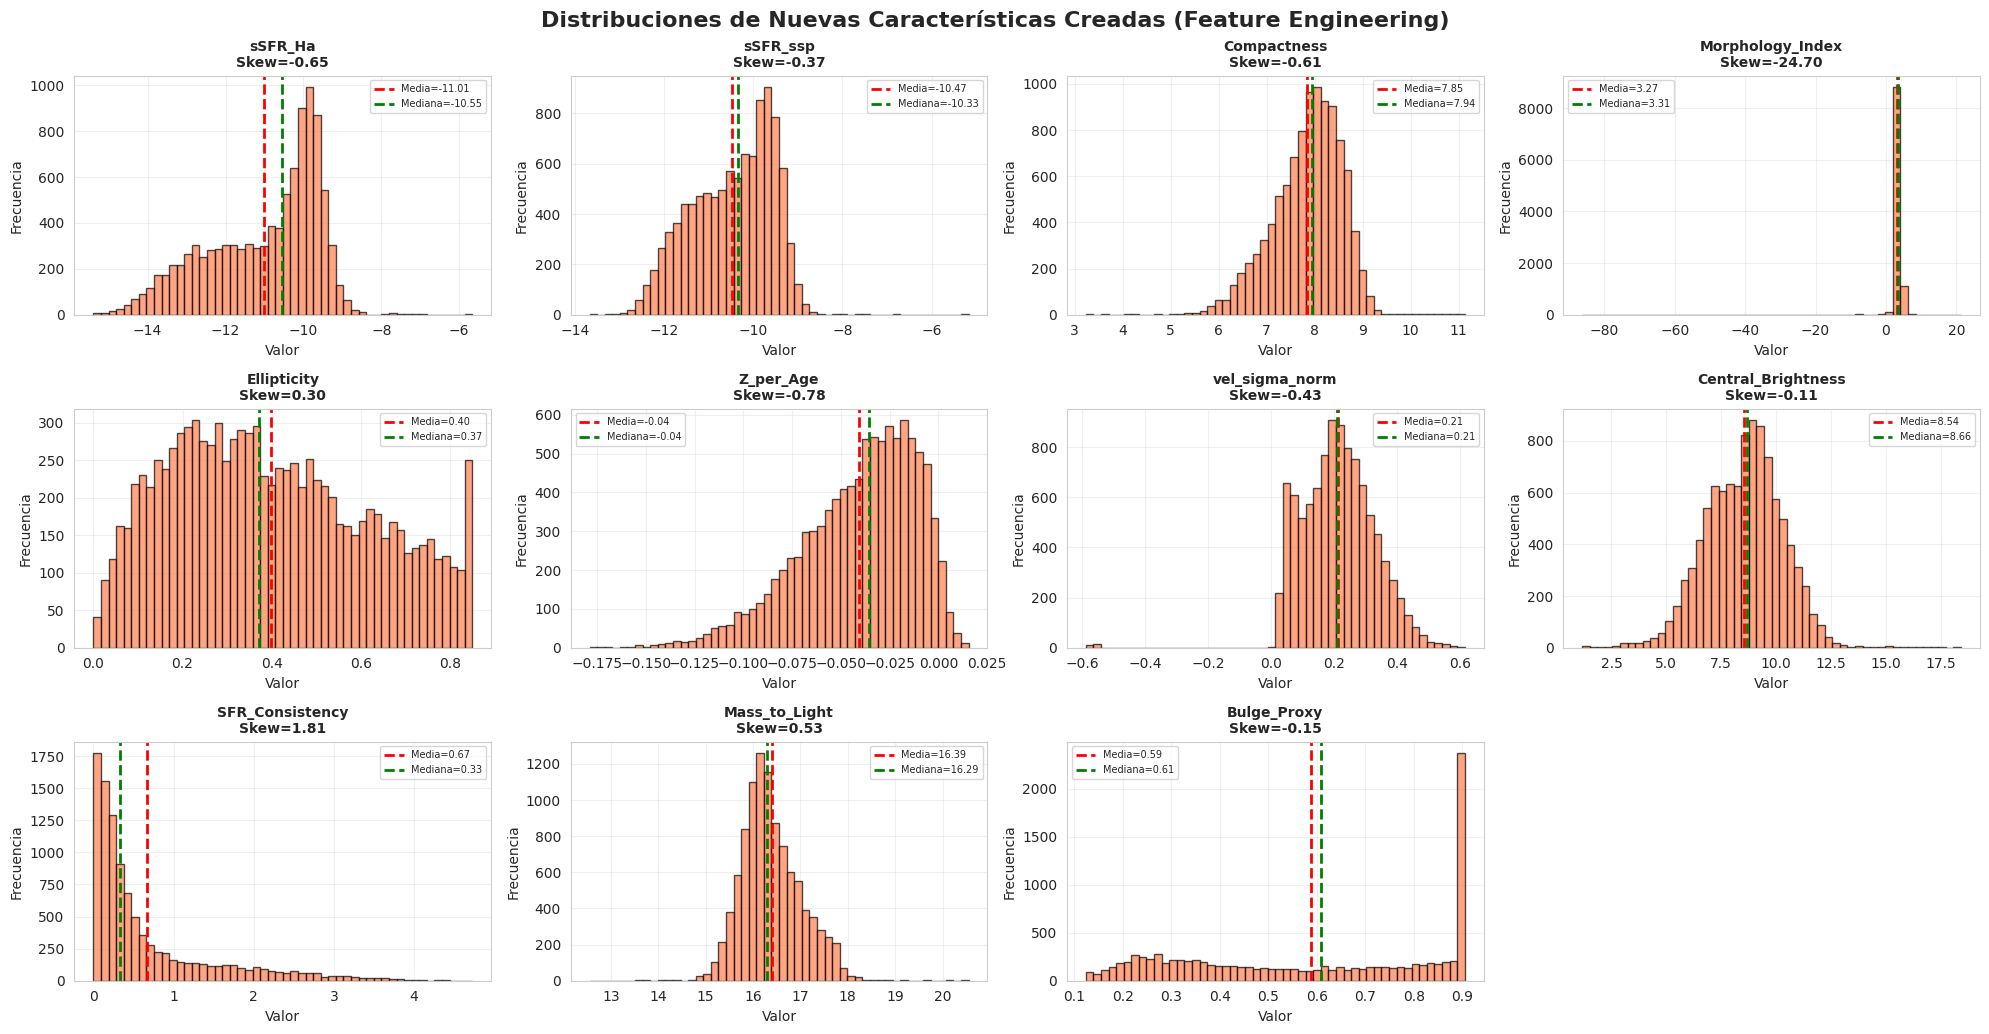


Estadísticas de nuevas características:

         sSFR_Ha   sSFR_ssp  Compactness  Morphology_Index  Ellipticity  \
count  10126.000  10126.000    10126.000         10126.000    10126.000   
mean     -11.012    -10.474        7.849             3.265        0.398   
std        1.426      0.904        0.703             2.273        0.220   
min      -15.394    -13.669        3.232           -86.337        0.000   
25%      -12.095    -11.182        7.423             2.900        0.219   
50%      -10.549    -10.331        7.939             3.307        0.371   
75%       -9.864     -9.720        8.358             3.758        0.564   
max       -5.665     -5.174       11.126            21.356        0.850   

       Z_per_Age  vel_sigma_norm  Central_Brightness  SFR_Consistency  \
count  10126.000       10126.000           10126.000        10126.000   
mean      -0.041           0.212               8.545            0.669   
std        0.030           0.114               1.751           

In [27]:
# Visualización de las nuevas características
print("\n VISUALIZACIÓN DE NUEVAS CARACTERÍSTICAS\n")

new_features = ['sSFR_Ha', 'sSFR_ssp', 'Compactness', 'Morphology_Index', 'Ellipticity',
                'Z_per_Age', 'vel_sigma_norm', 'Central_Brightness', 'SFR_Consistency',
                'Mass_to_Light', 'Bulge_Proxy']

# Histogramas de nuevas features
n_cols_grid = 4
n_rows_grid = int(np.ceil(len(new_features) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3.5))
axes = axes.flatten()

for idx, feat in enumerate(new_features):
    # Filtrar valores infinitos que puedan resultar de divisiones
    data = df_engineered[feat].replace([np.inf, -np.inf], np.nan).dropna()

    axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media={data.mean():.2f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana={data.median():.2f}')
    axes[idx].set_title(f'{feat}\nSkew={skew(data):.2f}', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(new_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribuciones de Nuevas Características Creadas (Feature Engineering)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas de nuevas features
print("\nEstadísticas de nuevas características:\n")
print(df_engineered[new_features].describe().round(3))

---

## 2. DISCRETIZACIÓN (BINNING)

### Justificación

La discretización convierte variables continuas en categóricas mediante la creación de "bins" o intervalos. Esto puede ser útil para:
- **Capturar relaciones no lineales** de forma simple
- **Reducir ruido** en mediciones continuas
- **Crear grupos astronómicamente significativos** (ej: galaxias masivas vs. enanas)
- **Facilitar interpretación** al agrupar valores en categorías físicamente relevantes

Aplicaremos discretización a variables clave donde las categorías tienen significado astronómico.

In [30]:
# Discretización de variables continuas en bins
print("DISCRETIZACIÓN (BINNING) DE VARIABLES CONTINUAS")
print("\n")

df_binned = df_engineered.copy()

# 1. Binning de Masa (LogMass) - Clasificación astronómica estándar
# Enanas: <9.5, Intermedias: 9.5-10.5, Masivas: 10.5-11.5, Super-masivas: >11.5
mass_bins = [0, 9.5, 10.5, 11.5, 15]
mass_labels = ['Enana', 'Intermedia', 'Masiva', 'SuperMasiva']
df_binned['Mass_Category'] = pd.cut(df_binned['LogMass'], bins=mass_bins, labels=mass_labels)
print(" Mass_Category creado con 4 bins:")
print(f"  {df_binned['Mass_Category'].value_counts().to_dict()}\n")

# 2. Binning de Edad estelar (log_age_mean_LW)
# Joven: <9, Media: 9-9.5, Vieja: >9.5 (en log años)
age_bins = [0, 9.0, 9.5, 12]
age_labels = ['Joven', 'Media', 'Vieja']
df_binned['Age_Category'] = pd.cut(df_binned['log_age_mean_LW'], bins=age_bins, labels=age_labels)
print(" Age_Category creado con 3 bins:")
print(f"  {df_binned['Age_Category'].value_counts().to_dict()}\n")

# 3. Binning de Índice de Sersic (morfología)
# n<2: Disco, 2<=n<4: Intermedia, n>=4: Esferoidal
sersic_bins = [0, 2, 4, 10]
sersic_labels = ['Disco', 'Intermedia', 'Esferoidal']
df_binned['Morphology_Category'] = pd.cut(df_binned['nsa_sersic_n'], bins=sersic_bins, labels=sersic_labels)
print(" Morphology_Category creado con 3 bins:")
print(f"  {df_binned['Morphology_Category'].value_counts().to_dict()}\n")

# 4. Binning de SFR - Actividad de formación estelar
# Pasiva: <-1, Moderada: -1 to 0.5, Activa: >0.5
sfr_bins = [-10, -1, 0.5, 5]
sfr_labels = ['Pasiva', 'Moderada', 'Activa']
df_binned['SFR_Category'] = pd.cut(df_binned['log_SFR_Ha'], bins=sfr_bins, labels=sfr_labels)
print(" SFR_Category creado con 3 bins:")
print(f"  {df_binned['SFR_Category'].value_counts().to_dict()}\n")

# 5. Binning cuantil (igual número de observaciones por bin) para Compactness
disc = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_binned['Compactness_Quantile'] = disc.fit_transform(df_binned[['Compactness']])
print(" Compactness_Quantile creado (4 bins por cuantiles):")
print(f"  {pd.Series(df_binned['Compactness_Quantile']).value_counts().sort_index().to_dict()}\n")


print(f"\n\nTotal de variables discretizadas: 5")
print(f"Dimensiones actuales: {df_binned.shape[0]:,} × {df_binned.shape[1]}")

DISCRETIZACIÓN (BINNING) DE VARIABLES CONTINUAS


 Mass_Category creado con 4 bins:
  {'Intermedia': 4301, 'Masiva': 3611, 'Enana': 2144, 'SuperMasiva': 70}

 Age_Category creado con 3 bins:
  {'Joven': 4705, 'Media': 3398, 'Vieja': 2023}

 Morphology_Category creado con 3 bins:
  {'Disco': 3922, 'Esferoidal': 3782, 'Intermedia': 2422}

 SFR_Category creado con 3 bins:
  {'Moderada': 5393, 'Pasiva': 3697, 'Activa': 1036}

 Compactness_Quantile creado (4 bins por cuantiles):
  {0.0: 2532, 1.0: 2531, 2.0: 2531, 3.0: 2532}



Total de variables discretizadas: 5
Dimensiones actuales: 10,126 × 33



 VISUALIZACIÓN DE VARIABLES DISCRETIZADAS



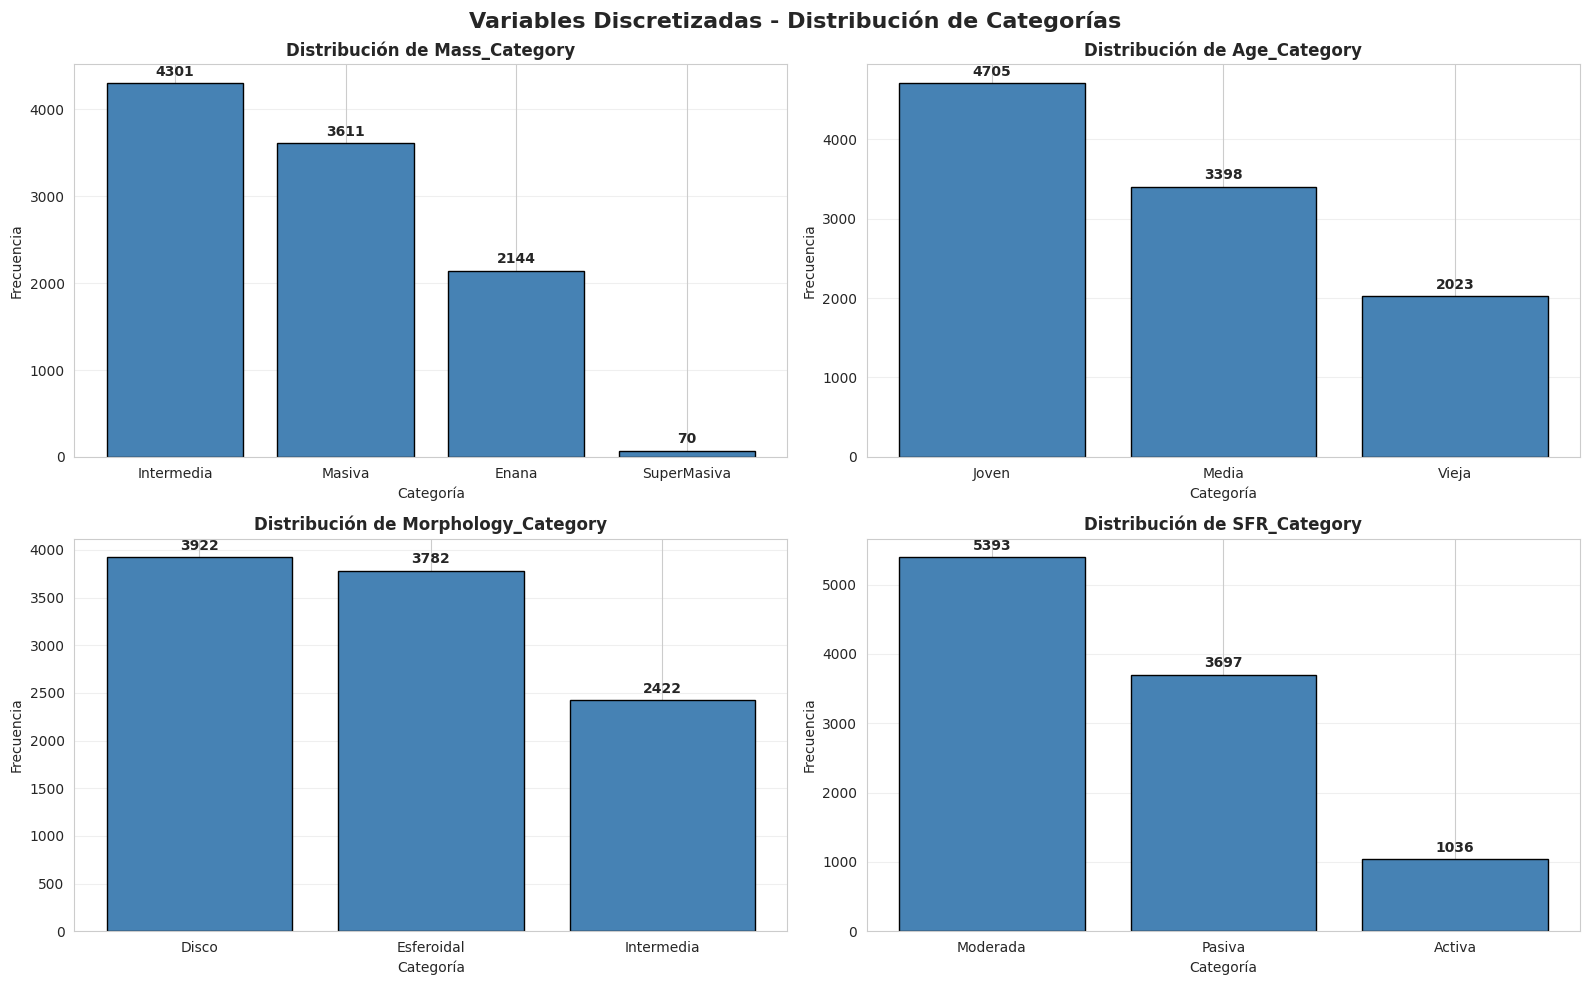

In [31]:
# Visualización de distribuciones discretizadas
print("\n VISUALIZACIÓN DE VARIABLES DISCRETIZADAS\n")

categorical_vars = ['Mass_Category', 'Age_Category', 'Morphology_Category', 'SFR_Category']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    counts = df_binned[var].value_counts()
    axes[idx].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {var}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Categoría')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

    # Añadir valores en las barras
    for i, (cat, val) in enumerate(zip(counts.index.astype(str), counts.values)):
        axes[idx].text(i, val + max(counts.values)*0.02, str(val),
                      ha='center', fontweight='bold')

plt.suptitle('Variables Discretizadas - Distribución de Categorías',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. CODIFICACIÓN DE VARIABLES CATEGÓRICAS

### Justificación

Los modelos de machine learning requieren entrada numérica. Las variables categóricas creadas mediante discretización deben ser codificadas:

- **Ordinal Encoding**: Para categorías con orden natural (Enana < Intermedia < Masiva)
- **One-Hot Encoding**: Para categorías sin orden inherente
- **Label Encoding**: Versión simplificada para ciertas categorías

Aplicaremos codificación ordinal a categorías con orden físico (masa, edad) y one-hot a categorías sin jerarquía clara.

In [34]:
# Codificación de variables categóricas
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("\n")

df_encoded = df_binned.copy()

# 1. ORDINAL ENCODING - Para variables con orden natural
print(" ORDINAL ENCODING (variables con orden jerárquico):\n")

# Mass_Category tiene orden natural: Enana < Intermedia < Masiva < SuperMasiva
mass_order = ['Enana', 'Intermedia', 'Masiva', 'SuperMasiva']
df_encoded['Mass_Category_Ord'] = df_encoded['Mass_Category'].cat.codes
print(f" Mass_Category_Ord: {dict(enumerate(mass_order))}")

# Age_Category tiene orden: Joven < Media < Vieja
age_order = ['Joven', 'Media', 'Vieja']
df_encoded['Age_Category_Ord'] = df_encoded['Age_Category'].cat.codes
print(f" Age_Category_Ord: {dict(enumerate(age_order))}")

# SFR_Category tiene orden: Pasiva < Moderada < Activa
sfr_order = ['Pasiva', 'Moderada', 'Activa']
df_encoded['SFR_Category_Ord'] = df_encoded['SFR_Category'].cat.codes
print(f" SFR_Category_Ord: {dict(enumerate(sfr_order))}\n")

# 2. ONE-HOT ENCODING - Para Morphology_Category (sin orden claro)
print(" ONE-HOT ENCODING (variables sin jerarquía natural):\n")

# One-hot para morfología
morphology_dummies = pd.get_dummies(df_encoded['Morphology_Category'],
                                     prefix='Morph', drop_first=False)
df_encoded = pd.concat([df_encoded, morphology_dummies], axis=1)
print(f" Morphology one-hot creado: {list(morphology_dummies.columns)}\n")


print(f"\nVariables codificadas: Ordinal (3), One-Hot (3 columnas de morfología)")
print(f"Dimensiones actuales: {df_encoded.shape[0]:,} × {df_encoded.shape[1]}")


CODIFICACIÓN DE VARIABLES CATEGÓRICAS


 ORDINAL ENCODING (variables con orden jerárquico):

 Mass_Category_Ord: {0: 'Enana', 1: 'Intermedia', 2: 'Masiva', 3: 'SuperMasiva'}
 Age_Category_Ord: {0: 'Joven', 1: 'Media', 2: 'Vieja'}
 SFR_Category_Ord: {0: 'Pasiva', 1: 'Moderada', 2: 'Activa'}

 ONE-HOT ENCODING (variables sin jerarquía natural):

 Morphology one-hot creado: ['Morph_Disco', 'Morph_Intermedia', 'Morph_Esferoidal']


Variables codificadas: Ordinal (3), One-Hot (3 columnas de morfología)
Dimensiones actuales: 10,126 × 39


---

## 4. TRANSFORMACIONES PARA NORMALIZAR DISTRIBUCIONES

### Justificación

Las distribuciones sesgadas identificadas en el EDA pueden afectar negativamente el rendimiento de modelos:
- **Problemas numéricos** en optimización (gradientes inestables)
- **Sesgo en predicciones** hacia valores más frecuentes
- **Convergencia lenta** en algoritmos iterativos

Aplicaremos transformaciones para normalizar distribuciones:
- **Yeo-Johnson**: Maneja valores positivos y negativos (más general que Box-Cox)
- **Quantile Transformer**: Mapea a distribución uniforme o normal
- **Power Transformer**: Estabiliza varianza y reduce sesgo

In [36]:
# Aplicación de transformaciones avanzadas
print("TRANSFORMACIONES PARA NORMALIZACIÓN DE DISTRIBUCIONES")
print("\n")

# Seleccionar solo variables numéricas (excluyendo categorías y coordenadas)
cols_to_transform = [col for col in df_encoded.columns
                     if col in numeric_cols and col not in ['objra', 'objdec', 'name']]

print(f"Variables a transformar: {len(cols_to_transform)}\n")

# 1. YEO-JOHNSON TRANSFORMATION (maneja positivos y negativos)
print(" Aplicando Yeo-Johnson Transformation...")
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
df_yj = df_encoded.copy()
df_yj[cols_to_transform] = pt_yj.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos transformados y estandarizados\n")

# 2. QUANTILE TRANSFORMATION (mapea a distribución uniforme)
print(" Aplicando Quantile Transformation (uniform)...")
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)
df_qt_uniform = df_encoded.copy()
df_qt_uniform[cols_to_transform] = qt_uniform.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos mapeados a distribución uniforme [0,1]\n")

# 3. QUANTILE TRANSFORMATION (mapea a distribución normal)
print(" Aplicando Quantile Transformation (normal)...")
qt_normal = QuantileTransformer(output_distribution='normal', random_state=42)
df_qt_normal = df_encoded.copy()
df_qt_normal[cols_to_transform] = qt_normal.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos mapeados a distribución normal\n")

print("\n\n")
print("Transformaciones completadas:")
print("  1. df_yj: Yeo-Johnson + Standardization")
print("  2. df_qt_uniform: Quantile → Uniform [0,1]")
print("  3. df_qt_normal: Quantile → Normal (μ=0, σ=1)")


TRANSFORMACIONES PARA NORMALIZACIÓN DE DISTRIBUCIONES


Variables a transformar: 14

 Aplicando Yeo-Johnson Transformation...
   Completado: Datos transformados y estandarizados

 Aplicando Quantile Transformation (uniform)...
   Completado: Datos mapeados a distribución uniforme [0,1]

 Aplicando Quantile Transformation (normal)...
   Completado: Datos mapeados a distribución normal




Transformaciones completadas:
  1. df_yj: Yeo-Johnson + Standardization
  2. df_qt_uniform: Quantile → Uniform [0,1]
  3. df_qt_normal: Quantile → Normal (μ=0, σ=1)



 COMPARACIÓN DE DISTRIBUCIONES (ANTES vs DESPUÉS)



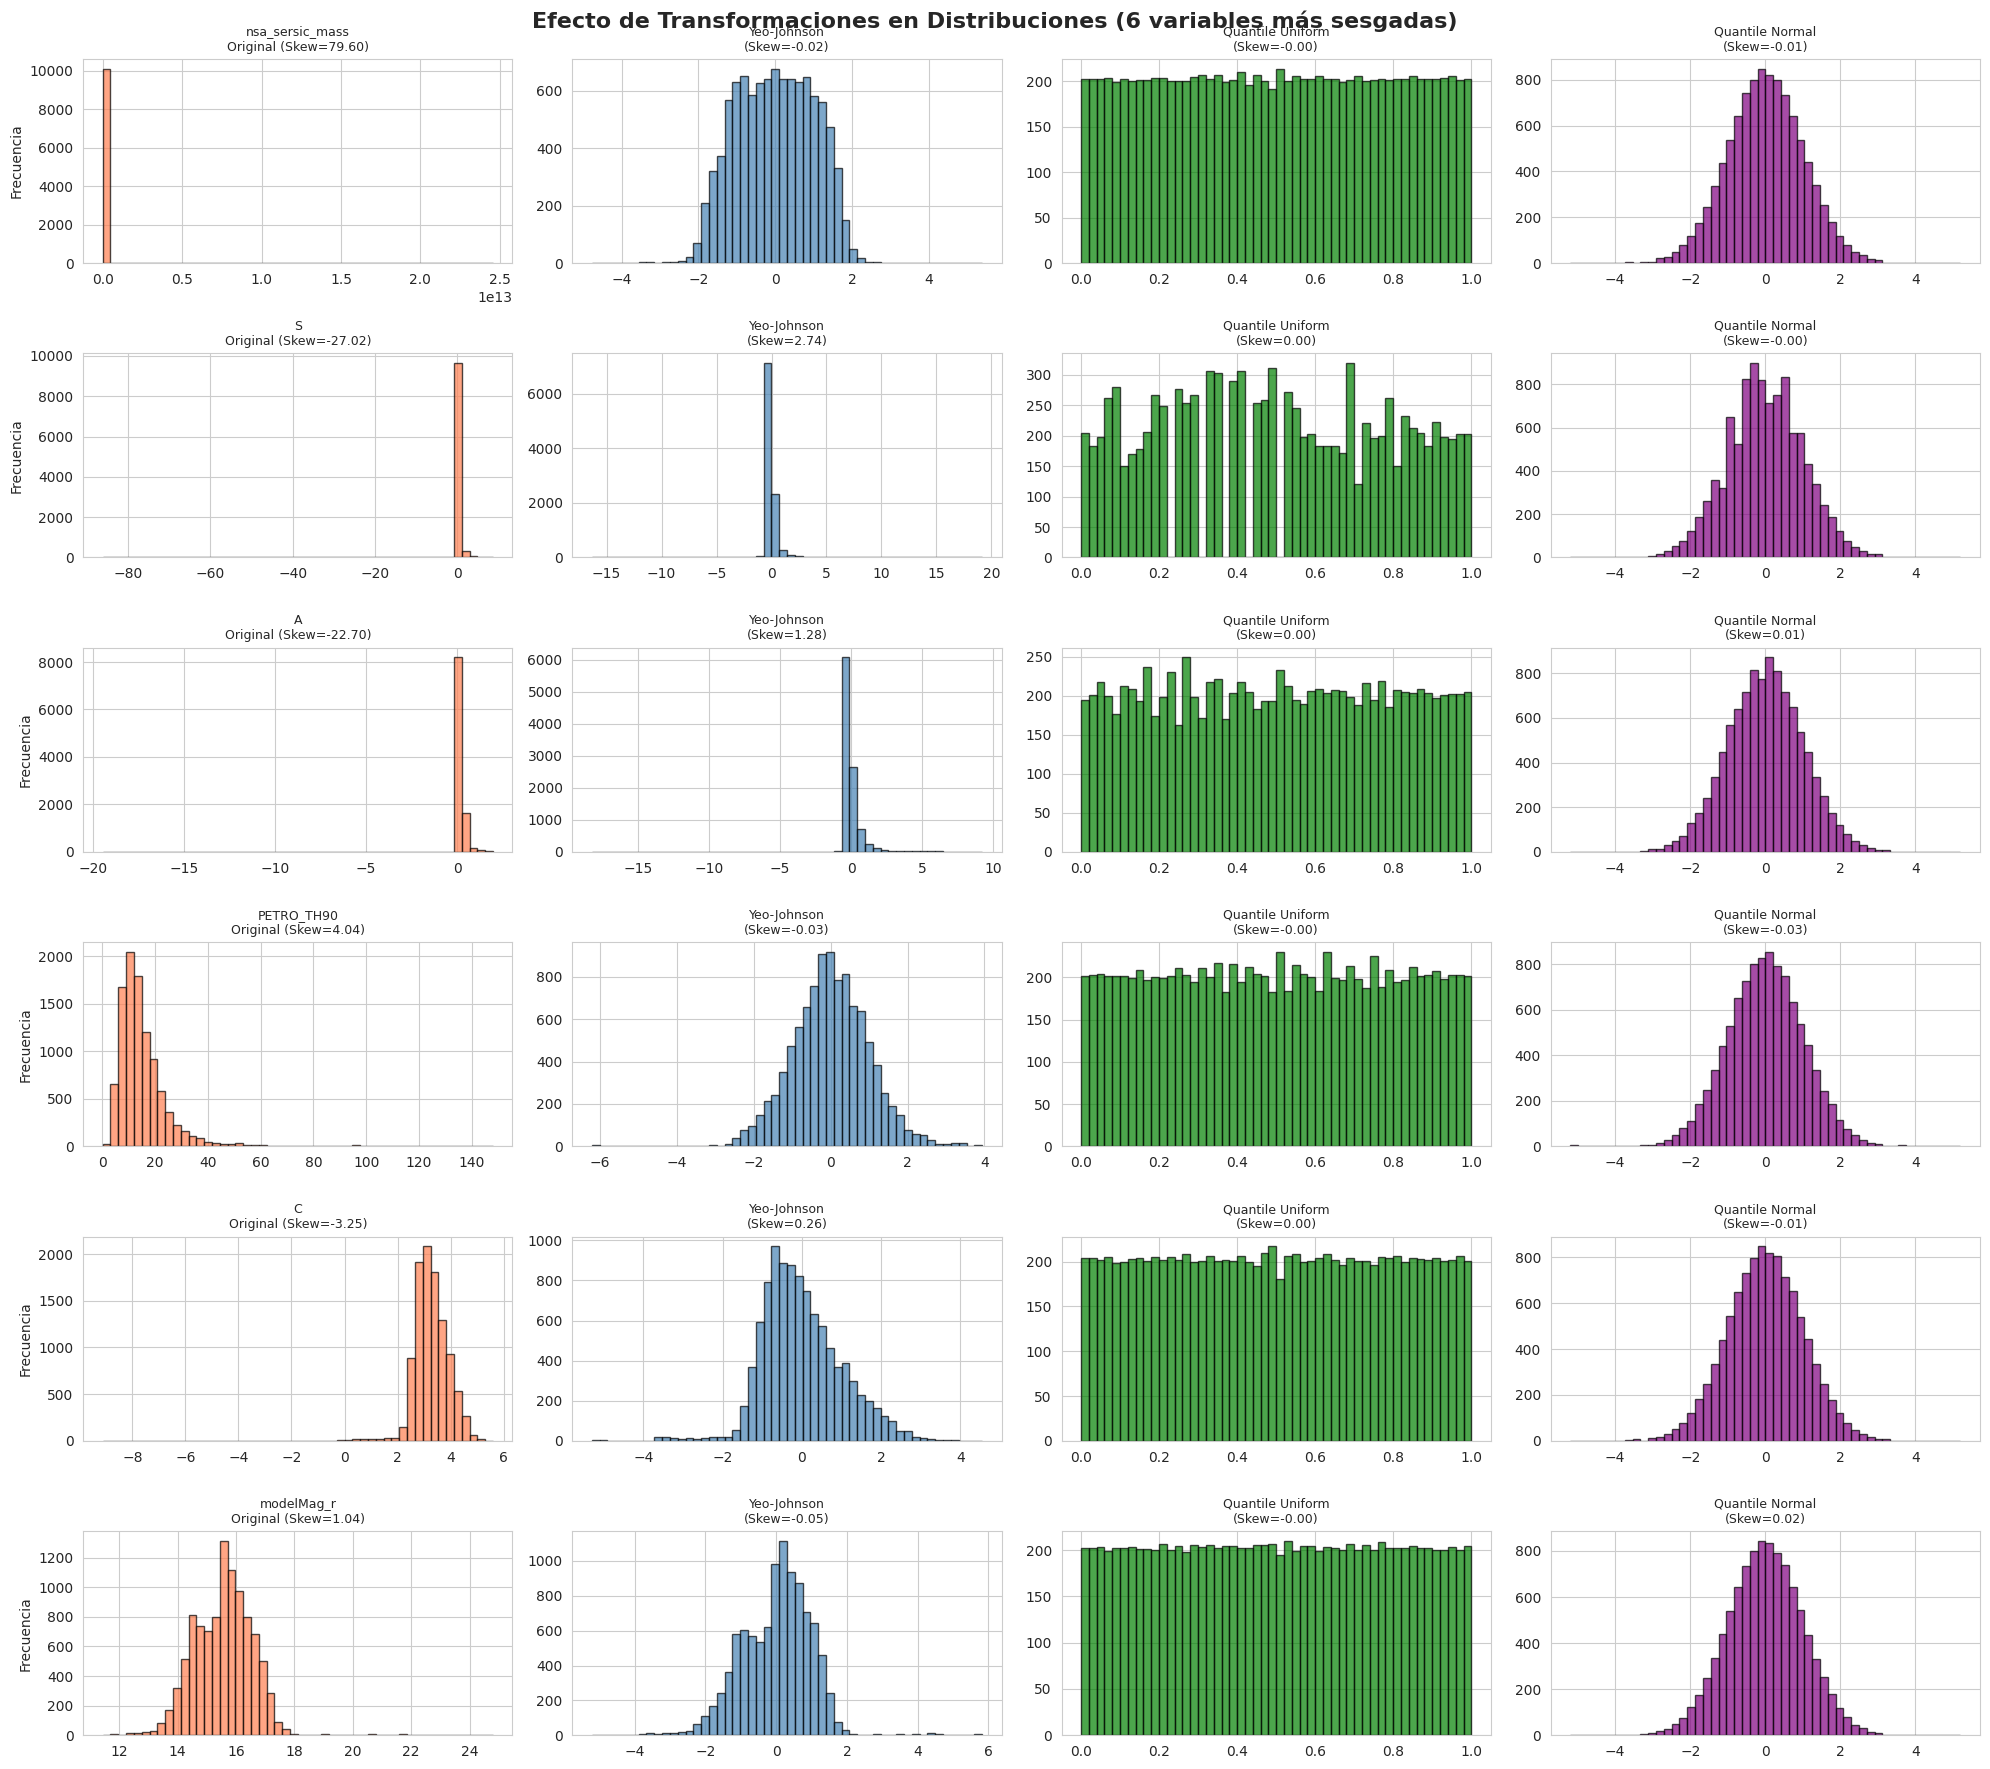


 Observaciones:
  - Original: Distribuciones altamente sesgadas
  - Yeo-Johnson: Reduce asimetría, estandariza
  - Quantile Uniform: Distribución plana en [0,1]
  - Quantile Normal: Distribución similar a campana de Gauss


In [37]:
# Comparación de distribuciones antes y después de transformaciones
print("\n COMPARACIÓN DE DISTRIBUCIONES (ANTES vs DESPUÉS)\n")

# Seleccionar variables con mayor asimetría para mostrar el efecto
skewness_original = df_encoded[cols_to_transform].apply(lambda x: np.abs(skew(x.dropna())))
top_skewed = skewness_original.nlargest(6).index.tolist()

fig, axes = plt.subplots(6, 4, figsize=(20, 18))

for idx, var in enumerate(top_skewed):
    # Original
    axes[idx, 0].hist(df_encoded[var].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{var}\nOriginal (Skew={skew(df_encoded[var].dropna()):.2f})', fontsize=9)
    axes[idx, 0].set_ylabel('Frecuencia')

    # Yeo-Johnson
    axes[idx, 1].hist(df_yj[var].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'Yeo-Johnson\n(Skew={skew(df_yj[var].dropna()):.2f})', fontsize=9)

    # Quantile Uniform
    axes[idx, 2].hist(df_qt_uniform[var].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[idx, 2].set_title(f'Quantile Uniform\n(Skew={skew(df_qt_uniform[var].dropna()):.2f})', fontsize=9)

    # Quantile Normal
    axes[idx, 3].hist(df_qt_normal[var].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[idx, 3].set_title(f'Quantile Normal\n(Skew={skew(df_qt_normal[var].dropna()):.2f})', fontsize=9)

plt.suptitle('Efecto de Transformaciones en Distribuciones (6 variables más sesgadas)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Observaciones:")
print("  - Original: Distribuciones altamente sesgadas")
print("  - Yeo-Johnson: Reduce asimetría, estandariza")
print("  - Quantile Uniform: Distribución plana en [0,1]")
print("  - Quantile Normal: Distribución similar a campana de Gauss")

---

---

## 5. SELECCIÓN DE CARACTERÍSTICAS (FEATURE SELECTION)

### Justificación

Con más de 30 características (originales + engineered), corremos el riesgo de:
- **Overfitting**: Modelo muy complejo que memoriza ruido
- **Curse of dimensionality**: Rendimiento degradado con muchas features
- **Tiempo de entrenamiento** excesivo
- **Interpretabilidad reducida**

Aplicaremos métodos complementarios de selección:
1. **Filter Methods**: Variance Threshold, Correlación, F-test (ANOVA)
2. **Wrapper Methods**: RFE (Recursive Feature Elimination)
3. **Embedded Methods**: Lasso, Random Forest Feature Importance
4. **Information Theory**: Mutual Information

Cada método captura diferentes aspectos de relevancia de features.

### 5.1 Umbral de Varianza (Variance Threshold)

**Fundamento:** Features con varianza muy baja (casi constantes) no aportan información discriminativa.

**Criterio:** Eliminar features con varianza < threshold (usaremos 0.01 para datos normalizados)

In [39]:
# Método 1: Variance Threshold
print("MÉTODO 1: VARIANCE THRESHOLD (Umbral de Varianza)")
print("\n")

# Usar el dataset transformado con Yeo-Johnson (ya estandarizado)
features_numeric = [col for col in df_yj.columns
                    if col in cols_to_transform]

X_var = df_yj[features_numeric]

# Aplicar umbral de varianza (0.01 para datos estandarizados)
var_threshold = 0.01
selector_var = VarianceThreshold(threshold=var_threshold)
X_var_selected = selector_var.fit_transform(X_var)

# Identificar features seleccionadas
selected_var = X_var.columns[selector_var.get_support()].tolist()
removed_var = X_var.columns[~selector_var.get_support()].tolist()

print(f"Threshold de varianza: {var_threshold}")
print(f"Features originales: {len(features_numeric)}")
print(f"Features seleccionadas: {len(selected_var)}")
print(f"Features eliminadas: {len(removed_var)}\n")

if removed_var:
    print("Features eliminadas por baja varianza:")
    for feat in removed_var:
        variance = X_var[feat].var()
        print(f"  - {feat}: varianza = {variance:.6f}")
else:
    print(" Todas las features superan el umbral de varianza.")

MÉTODO 1: VARIANCE THRESHOLD (Umbral de Varianza)


Threshold de varianza: 0.01
Features originales: 14
Features seleccionadas: 14
Features eliminadas: 0

 Todas las features superan el umbral de varianza.


### 5.2 Filtro por Correlación

**Fundamento:** Features altamente correlacionadas son redundantes. Una puede ser eliminada sin pérdida significativa de información.

**Criterio:** Si |correlación| > 0.95, eliminar una del par (mantener la que tiene mayor correlación con targets)

In [40]:
# Método 2: Filtro por Correlación Alta
print("MÉTODO 2: FILTRO POR CORRELACIÓN ALTA (|r| > 0.95)")
print("\n")

# Calcular matriz de correlación
corr_matrix = df_yj[selected_var].corr().abs()

# Crear máscara triangular superior para evitar duplicados
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_corr = corr_matrix.where(upper_triangle)

# Identificar pares con correlación > 0.95
high_corr_pairs = []
to_drop_corr = set()

for column in upper_corr.columns:
    high_corr = upper_corr[column][upper_corr[column] > 0.95]
    if len(high_corr) > 0:
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, upper_corr.loc[idx, column]))
            # Decidir cuál eliminar (arbitrariamente el segundo)
            to_drop_corr.add(idx)

print(f"Pares de features con |r| > 0.95: {len(high_corr_pairs)}\n")

if high_corr_pairs:
    print("Pares altamente correlacionados:")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  - {feat1} ↔ {feat2}: r = {corr_val:.3f}")
    print(f"\nFeatures a eliminar por alta correlación: {len(to_drop_corr)}")
    print(f"  {list(to_drop_corr)}")
else:
    print(" No se detectaron pares de features con correlación > 0.95")

# Features después de filtro de correlación
selected_after_corr = [f for f in selected_var if f not in to_drop_corr]
print(f"\nFeatures restantes tras filtro de correlación: {len(selected_after_corr)}")

MÉTODO 2: FILTRO POR CORRELACIÓN ALTA (|r| > 0.95)


Pares de features con |r| > 0.95: 1

Pares altamente correlacionados:
  - LogMass ↔ nsa_sersic_mass: r = 1.000

Features a eliminar por alta correlación: 1
  ['nsa_sersic_mass']

Features restantes tras filtro de correlación: 13


### 5.3 F-test para Regresión (ANOVA)

**Fundamento:** Prueba estadística que evalúa la relación lineal entre cada feature y la variable target.

**Criterio:** Seleccionar las K features con mayor F-score (mayor relación lineal con el target)

**Variable target:** Usaremos `LogMass` como variable objetivo principal (masa es una propiedad fundamental)

In [41]:
# Método 3: F-test (ANOVA) para regresión
print("MÉTODO 3: F-TEST (ANOVA) PARA REGRESIÓN")
print("\n")

# Definir target (LogMass como objetivo principal)
target_var = 'LogMass'
X_anova = df_yj[selected_after_corr].drop(columns=[target_var], errors='ignore')
y_anova = df_yj[target_var]

# Aplicar F-test
k_best = min(20, len(X_anova.columns))  # Seleccionar top 20 o todas si hay menos
selector_anova = SelectKBest(score_func=f_regression, k=k_best)
selector_anova.fit(X_anova, y_anova)

# Obtener scores
f_scores = pd.DataFrame({
    'Feature': X_anova.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

print(f"Variable objetivo: {target_var}")
print(f"Features evaluadas: {len(X_anova.columns)}")
print(f"Top {k_best} features seleccionadas\n")

print("Top 15 features por F-Score:\n")
print(f_scores.head(15).to_string(index=False))

# Features seleccionadas
selected_anova = X_anova.columns[selector_anova.get_support()].tolist()
print(f"\nTotal features seleccionadas: {len(selected_anova)}")

MÉTODO 3: F-TEST (ANOVA) PARA REGRESIÓN


Variable objetivo: LogMass
Features evaluadas: 12
Top 12 features seleccionadas

Top 15 features por F-Score:

        Feature   F_Score     P_Value
 log_ZH_mean_LW 6627.1145  0.0000e+00
log_age_mean_LW 6488.6281  0.0000e+00
   nsa_sersic_n 6144.2982  0.0000e+00
              C 4687.6966  0.0000e+00
   vel_sigma_Re 3302.3622  0.0000e+00
     modelMag_r 2915.1468  0.0000e+00
     PETRO_TH90 1366.9060 8.7183e-281
  nsa_sersic_ba  987.7563 5.8187e-207
    log_SFR_ssp  441.3963  5.8944e-96
     log_SFR_Ha   23.6413  1.1782e-06
              S    7.9903  4.7121e-03
              A    0.0576  8.1038e-01

Total features seleccionadas: 12


### 5.4 Información Mutua (Mutual Information)

**Fundamento:** Mide la dependencia (lineal y no lineal) entre features y target. Captura relaciones que correlación lineal podría perder.

**Ventaja:** Detecta relaciones no lineales complejas

**Criterio:** Seleccionar features con alta MI (>0.1 para datos normalizados)

In [42]:
# Método 4: Mutual Information
print("MÉTODO 4: MUTUAL INFORMATION (Información Mutua)")
print("\n")

# Calcular información mutua
mi_scores = mutual_info_regression(X_anova, y_anova, random_state=42)
mi_scores_df = pd.DataFrame({
    'Feature': X_anova.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"Variable objetivo: {target_var}")
print(f"Features evaluadas: {len(X_anova.columns)}\n")

print("Top 15 features por Mutual Information:\n")
print(mi_scores_df.head(15).to_string(index=False))

# Seleccionar features con MI > 0.05
mi_threshold = 0.05
selected_mi = mi_scores_df[mi_scores_df['MI_Score'] > mi_threshold]['Feature'].tolist()
print(f"\nFeatures con MI > {mi_threshold}: {len(selected_mi)}")

MÉTODO 4: MUTUAL INFORMATION (Información Mutua)


Variable objetivo: LogMass
Features evaluadas: 12

Top 15 features por Mutual Information:

        Feature  MI_Score
     modelMag_r    0.3754
 log_ZH_mean_LW    0.2943
   nsa_sersic_n    0.2724
log_age_mean_LW    0.2625
              C    0.2381
   vel_sigma_Re    0.2059
     log_SFR_Ha    0.1782
     PETRO_TH90    0.1448
    log_SFR_ssp    0.1200
  nsa_sersic_ba    0.0775
              S    0.0295
              A    0.0267

Features con MI > 0.05: 10



 COMPARACIÓN DE MÉTODOS DE SELECCIÓN



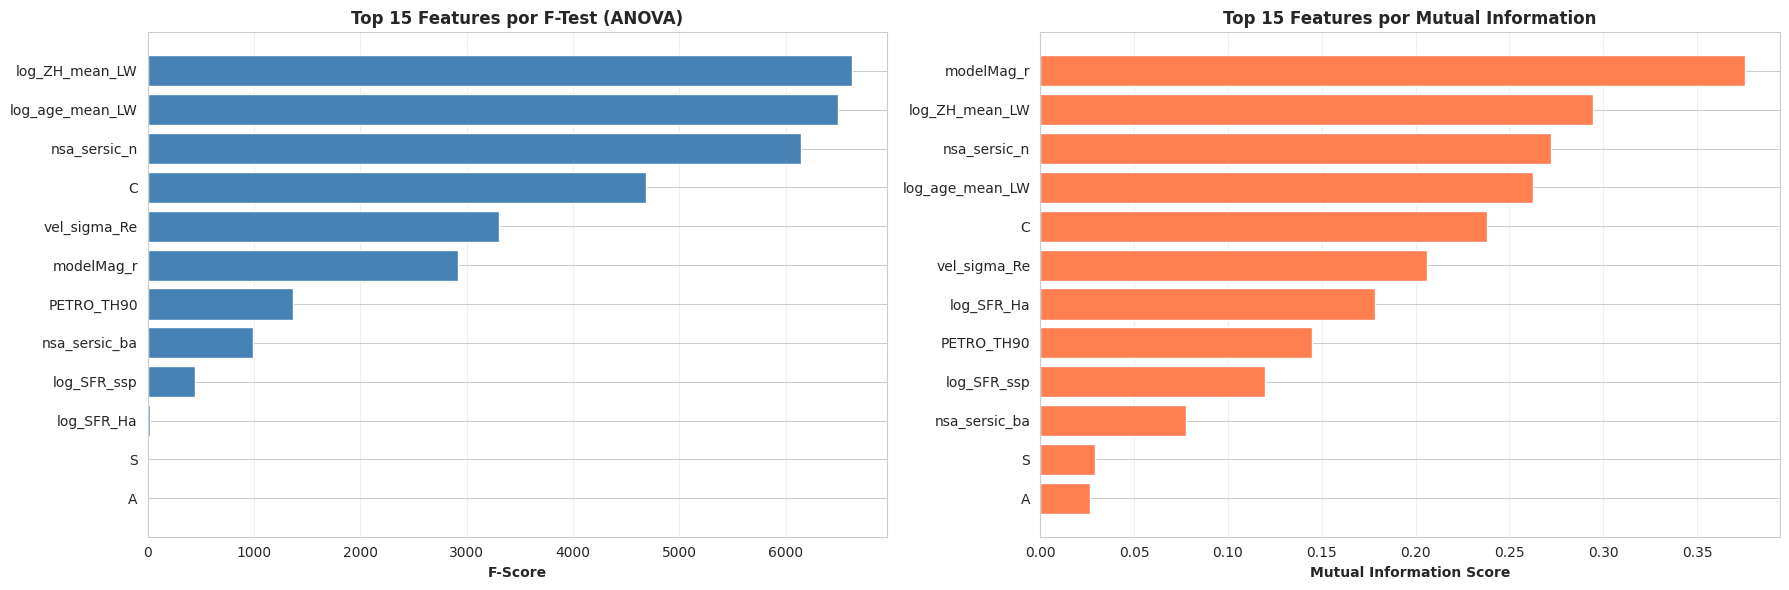


 ANÁLISIS DE CONSENSO ENTRE MÉTODOS:

Features en Top 15 de F-test: 12
Features en Top 15 de MI: 12
Features en Top 15 de AMBOS métodos: 12

Features de consenso (en top 15 de ambos):
   A
   C
   PETRO_TH90
   S
   log_SFR_Ha
   log_SFR_ssp
   log_ZH_mean_LW
   log_age_mean_LW
   modelMag_r
   nsa_sersic_ba
   nsa_sersic_n
   vel_sigma_Re


In [43]:
# Visualización comparativa de métodos de selección
print("\n COMPARACIÓN DE MÉTODOS DE SELECCIÓN\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: F-Scores
top_15_f = f_scores.head(15)
axes[0].barh(range(len(top_15_f)), top_15_f['F_Score'], color='steelblue')
axes[0].set_yticks(range(len(top_15_f)))
axes[0].set_yticklabels(top_15_f['Feature'])
axes[0].set_xlabel('F-Score', fontweight='bold')
axes[0].set_title('Top 15 Features por F-Test (ANOVA)', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Mutual Information
top_15_mi = mi_scores_df.head(15)
axes[1].barh(range(len(top_15_mi)), top_15_mi['MI_Score'], color='coral')
axes[1].set_yticks(range(len(top_15_mi)))
axes[1].set_yticklabels(top_15_mi['Feature'])
axes[1].set_xlabel('Mutual Information Score', fontweight='bold')
axes[1].set_title('Top 15 Features por Mutual Information', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de consenso
print("\n ANÁLISIS DE CONSENSO ENTRE MÉTODOS:\n")
print("="*70)

# Features en top 15 de ambos métodos
top_f = set(f_scores.head(15)['Feature'])
top_mi = set(mi_scores_df.head(15)['Feature'])
consensus_top = top_f.intersection(top_mi)

print(f"Features en Top 15 de F-test: {len(top_f)}")
print(f"Features en Top 15 de MI: {len(top_mi)}")
print(f"Features en Top 15 de AMBOS métodos: {len(consensus_top)}\n")

if consensus_top:
    print("Features de consenso (en top 15 de ambos):")
    for feat in sorted(consensus_top):
        print(f"   {feat}")

print("="*70)

### 5.5 Random Forest Feature Importance (Embedded Method)

**Fundamento:** Los modelos de Random Forest calculan importancia basada en cuánto mejora cada feature la pureza de los splits.

**Ventaja:** Considera interacciones entre features, no solo relaciones univariadas

**Criterio:** Seleccionar features con importancia > threshold (o top K)

MÉTODO 5: RANDOM FOREST FEATURE IMPORTANCE (Embedded)


Entrenando Random Forest (esto puede tomar un momento)...

Top 15 features por Random Forest Importance:

        Feature  Importance
   nsa_sersic_n      0.2856
log_age_mean_LW      0.1922
    log_SFR_ssp      0.1850
     PETRO_TH90      0.1078
     modelMag_r      0.0813
     log_SFR_Ha      0.0679
 log_ZH_mean_LW      0.0345
   vel_sigma_Re      0.0141
              C      0.0127
              A      0.0087
  nsa_sersic_ba      0.0059
              S      0.0044


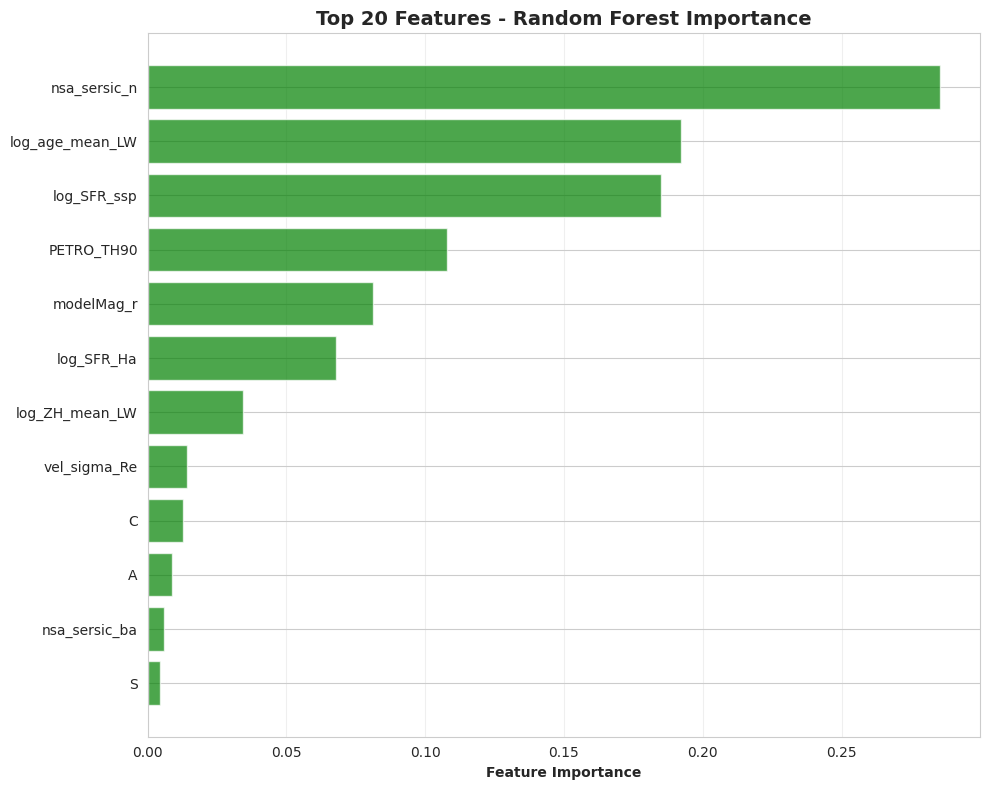


Features con importancia > 0.01: 9


In [44]:
# Método 5: Random Forest Feature Importance
print("MÉTODO 5: RANDOM FOREST FEATURE IMPORTANCE (Embedded)")
print("\n")

# Entrenar Random Forest para calcular importancia
print("Entrenando Random Forest (esto puede tomar un momento)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_anova, y_anova)

# Obtener importancias
rf_importances = pd.DataFrame({
    'Feature': X_anova.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 features por Random Forest Importance:\n")
print(rf_importances.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_20_rf = rf_importances.head(20)
ax.barh(range(len(top_20_rf)), top_20_rf['Importance'], color='green', alpha=0.7)
ax.set_yticks(range(len(top_20_rf)))
ax.set_yticklabels(top_20_rf['Feature'])
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('Top 20 Features - Random Forest Importance', fontweight='bold', fontsize=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccionar features con importancia > threshold
importance_threshold = 0.01
selected_rf = rf_importances[rf_importances['Importance'] > importance_threshold]['Feature'].tolist()
print(f"\nFeatures con importancia > {importance_threshold}: {len(selected_rf)}")

---

## 6. REDUCCIÓN DE DIMENSIONALIDAD

### Justificación

Aunque hemos seleccionado features relevantes, aún podemos tener alta dimensionalidad. La reducción de dimensionalidad:
- **Captura varianza principal** en menos dimensiones
- **Elimina ruido** y correlaciones redundantes
- **Acelera entrenamiento** significativamente
- **Visualización** de relaciones complejas

Aplicaremos dos técnicas complementarias:
1. **PCA (Principal Component Analysis)**: Proyección lineal que maximiza varianza
2. **Factor Analysis (FA)**: Modelo probabilístico que asume factores latentes

### 6.1 PCA (Principal Component Analysis)

**Fundamento:** Transforma features correlacionadas en componentes principales no correlacionados, ordenados por varianza explicada.

**Objetivo:** Retener 95% de varianza con menos componentes

**Interpretación:** Los primeros PCs capturan las direcciones de mayor variabilidad en los datos

In [45]:
# PCA - Principal Component Analysis
print("PCA (PRINCIPAL COMPONENT ANALYSIS)")
print("\n")

# Preparar datos: usar features seleccionadas por consenso
# Usar el dataset transformado (Yeo-Johnson)
X_pca = df_yj[selected_after_corr]

# Aplicar PCA para explicar 95% de varianza
pca = PCA(n_components=0.95, random_state=42)
X_pca_transformed = pca.fit_transform(X_pca)

print(f"Features originales: {X_pca.shape[1]}")
print(f"Componentes principales (95% varianza): {pca.n_components_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f}\n")

# Varianza explicada por componente
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(pca.n_components_)],
    'Varianza': pca.explained_variance_ratio_,
    'Varianza_Acum': np.cumsum(pca.explained_variance_ratio_)
})

print("Primeros 10 componentes principales:\n")
print(variance_df.head(10).to_string(index=False))

PCA (PRINCIPAL COMPONENT ANALYSIS)


Features originales: 13
Componentes principales (95% varianza): 10
Varianza total explicada: 0.9635

Primeros 10 componentes principales:

  PC  Varianza  Varianza_Acum
 PC1    0.3684         0.3684
 PC2    0.1599         0.5283
 PC3    0.1224         0.6506
 PC4    0.0796         0.7302
 PC5    0.0633         0.7935
 PC6    0.0565         0.8500
 PC7    0.0355         0.8856
 PC8    0.0293         0.9149
 PC9    0.0286         0.9435
PC10    0.0199         0.9635



 VISUALIZACIÓN DE PCA



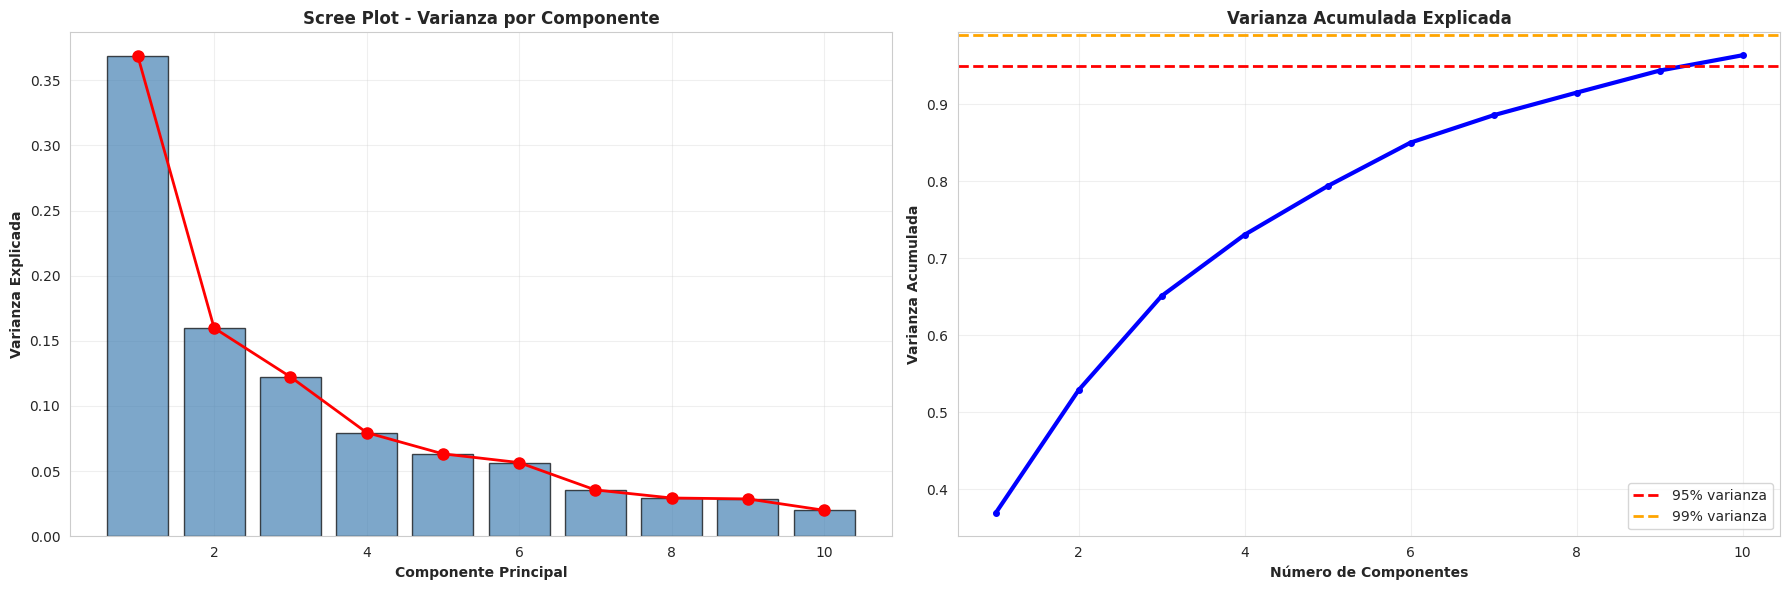


 INTERPRETACIÓN DE LOS PRIMEROS 3 COMPONENTES PRINCIPALES:


 PC1 (Varianza explicada: 0.3684):
  Top 5 features contribuyentes:
    - log_age_mean_LW: 0.415 (contribución positiva)
    - log_ZH_mean_LW: 0.375 (contribución positiva)
    - nsa_sersic_n: 0.374 (contribución positiva)
    - C: 0.352 (contribución positiva)
    - vel_sigma_Re: -0.339 (contribución negativa)

 PC2 (Varianza explicada: 0.1599):
  Top 5 features contribuyentes:
    - log_SFR_ssp: 0.521 (contribución positiva)
    - log_SFR_Ha: 0.497 (contribución positiva)
    - PETRO_TH90: 0.370 (contribución positiva)
    - LogMass: 0.338 (contribución positiva)
    - modelMag_r: -0.283 (contribución negativa)

 PC3 (Varianza explicada: 0.1224):
  Top 5 features contribuyentes:
    - S: 0.648 (contribución positiva)
    - A: 0.613 (contribución positiva)
    - log_SFR_Ha: -0.282 (contribución negativa)
    - log_SFR_ssp: -0.254 (contribución negativa)
    - modelMag_r: 0.129 (contribución positiva)


In [46]:
# Visualización de PCA
print("\n VISUALIZACIÓN DE PCA\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Scree plot (varianza por componente)
n_show = min(20, pca.n_components_)
axes[0].bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show],
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].plot(range(1, n_show+1), pca.explained_variance_ratio_[:n_show],
             'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada', fontweight='bold')
axes[0].set_title('Scree Plot - Varianza por Componente', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, pca.n_components_+1),
             np.cumsum(pca.explained_variance_ratio_),
             'b-', linewidth=3, marker='o', markersize=4)
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axhline(y=0.99, color='orange', linestyle='--', linewidth=2, label='99% varianza')
axes[1].set_xlabel('Número de Componentes', fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada', fontweight='bold')
axes[1].set_title('Varianza Acumulada Explicada', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación de componentes principales
print("\n INTERPRETACIÓN DE LOS PRIMEROS 3 COMPONENTES PRINCIPALES:\n")

for i in range(min(3, pca.n_components_)):
    print(f"\n PC{i+1} (Varianza explicada: {pca.explained_variance_ratio_[i]:.4f}):")

    # Obtener loadings (contribuciones de cada feature)
    loadings = pca.components_[i]
    feature_importance = pd.DataFrame({
        'Feature': X_pca.columns,
        'Loading': loadings,
        'Abs_Loading': np.abs(loadings)
    }).sort_values('Abs_Loading', ascending=False)

    print("  Top 5 features contribuyentes:")
    for idx, row in feature_importance.head(5).iterrows():
        direction = "positiva" if row['Loading'] > 0 else "negativa"
        print(f"    - {row['Feature']}: {row['Loading']:.3f} (contribución {direction})")



### 6.2 Factor Analysis (FA)

**Fundamento:** Asume que las variables observadas son manifestaciones de factores latentes no observables.

**Diferencia con PCA:**
- PCA: Proyección determinística, maximiza varianza
- FA: Modelo probabilístico, busca estructura latente

**Aplicación:** Útil cuando creemos que existe estructura causal subyacente (ej: masa, edad, morfología como factores fundamentales)

In [47]:
# Factor Analysis
print("FACTOR ANALYSIS (FA)")
print("\n")

# Número de factores (usar número similar a PCA)
n_factors = min(10, pca.n_components_)

# Aplicar Factor Analysis
fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=1000)
X_fa_transformed = fa.fit_transform(X_pca)

print(f"Features originales: {X_pca.shape[1]}")
print(f"Factores latentes: {n_factors}\n")

# Varianza explicada por cada factor (estimación)
# FA no calcula varianza explicada directamente, pero podemos estimar
fa_variance = np.var(X_fa_transformed, axis=0)
fa_variance_ratio = fa_variance / fa_variance.sum()

fa_variance_df = pd.DataFrame({
    'Factor': [f'Factor{i+1}' for i in range(n_factors)],
    'Varianza_Est': fa_variance,
    'Proporción': fa_variance_ratio,
    'Varianza_Acum': np.cumsum(fa_variance_ratio)
})

print("Factores latentes y varianza estimada:\n")
print(fa_variance_df.to_string(index=False))


FACTOR ANALYSIS (FA)


Features originales: 13
Factores latentes: 10

Factores latentes y varianza estimada:

  Factor  Varianza_Est  Proporción  Varianza_Acum
 Factor1        0.9756      0.1599         0.1599
 Factor2        0.9382      0.1537         0.3136
 Factor3        0.8077      0.1324         0.4459
 Factor4        0.7646      0.1253         0.5712
 Factor5        0.7569      0.1240         0.6953
 Factor6        0.5268      0.0863         0.7816
 Factor7        0.4642      0.0761         0.8577
 Factor8        0.4475      0.0733         0.9310
 Factor9        0.2530      0.0415         0.9724
Factor10        0.1681      0.0276         1.0000



 COMPARACIÓN PCA vs FACTOR ANALYSIS



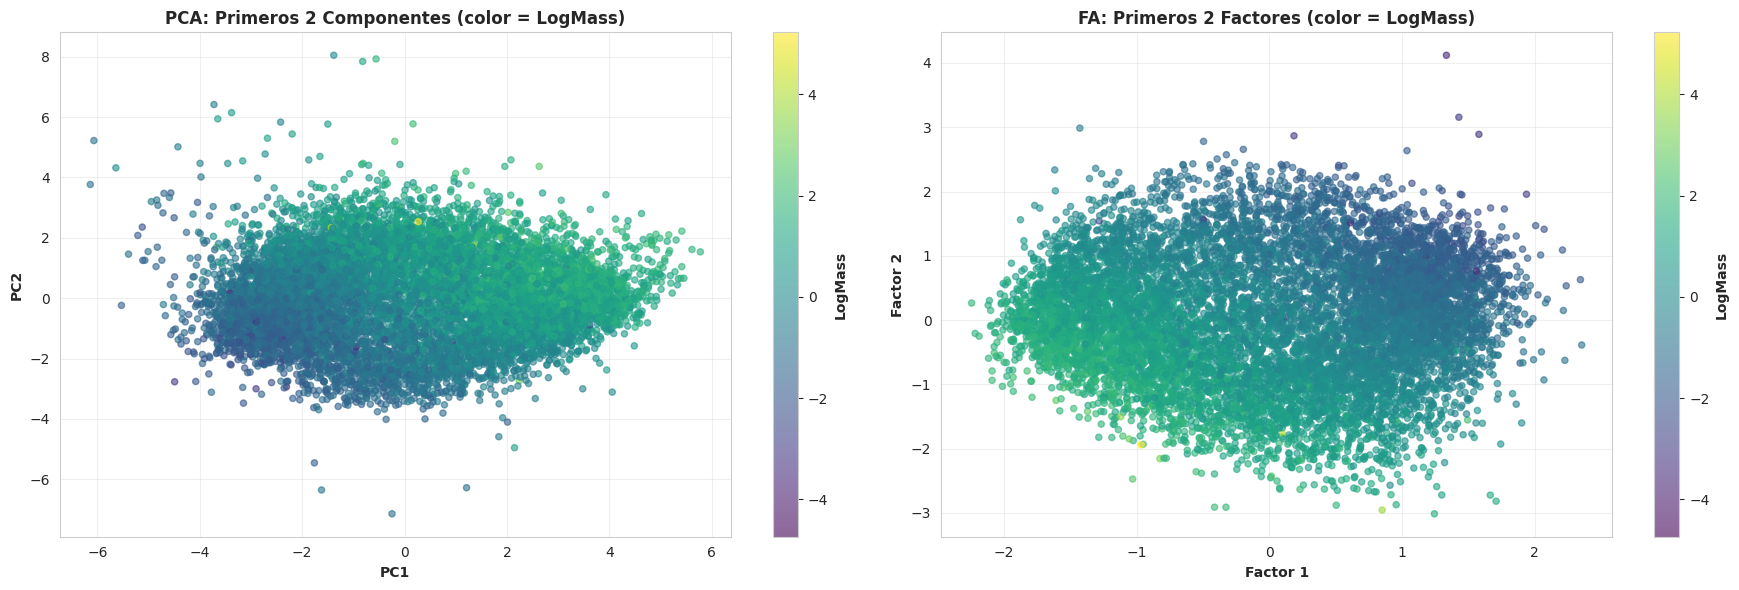


 Interpretación:
  - Ambas técnicas revelan estructura en los datos
  - PCA: Maximiza varianza, útil para compresión
  - FA: Busca factores causales latentes
  - El color muestra cómo LogMass se distribuye en el espacio reducido


In [48]:
# Visualización de Factor Analysis
print("\n COMPARACIÓN PCA vs FACTOR ANALYSIS\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter: PC1 vs PC2
axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                c=df_yj['LogMass'], cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel('PC1', fontweight='bold')
axes[0].set_ylabel('PC2', fontweight='bold')
axes[0].set_title('PCA: Primeros 2 Componentes (color = LogMass)', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)
cbar1 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar1.set_label('LogMass', fontweight='bold')

# Scatter: Factor1 vs Factor2
scatter2 = axes[1].scatter(X_fa_transformed[:, 0], X_fa_transformed[:, 1],
                          c=df_yj['LogMass'], cmap='viridis', alpha=0.6, s=20)
axes[1].set_xlabel('Factor 1', fontweight='bold')
axes[1].set_ylabel('Factor 2', fontweight='bold')
axes[1].set_title('FA: Primeros 2 Factores (color = LogMass)', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('LogMass', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Interpretación:")
print("  - Ambas técnicas revelan estructura en los datos")
print("  - PCA: Maximiza varianza, útil para compresión")
print("  - FA: Busca factores causales latentes")
print("  - El color muestra cómo LogMass se distribuye en el espacio reducido")

---

## 7. RESUMEN Y RECOMENDACIONES DE FEATURE SELECTION

### Síntesis de Métodos Aplicados

In [50]:
# Resumen final de feature selection
print("RESUMEN FINAL: FEATURE SELECTION Y REDUCCIÓN DE DIMENSIONALIDAD")
print("\n")

summary = {
    'Etapa': [
        '1. Features originales',
        '2. Features creadas (FE)',
        '3. Tras Variance Threshold',
        '4. Tras filtro de correlación',
        '5. Top K por F-test',
        '6. Con MI > threshold',
        '7. Con RF importance > threshold',
        '8. PCA (95% varianza)',
        '9. Factor Analysis'
    ],
    'N_Features': [
        len(numeric_cols),
        len(new_features),
        len(selected_var),
        len(selected_after_corr),
        len(selected_anova),
        len(selected_mi),
        len(selected_rf),
        pca.n_components_,
        n_factors
    ],
    'Reducción_%': [
        0,
        '+{:.1f}%'.format((len(new_features)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_var)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_after_corr)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_anova)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_mi)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_rf)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - pca.n_components_/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - n_factors/len(numeric_cols))*100)
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print("\n\n RECOMENDACIONES PARA MODELADO:\n")
print("1. **Para máximo rendimiento**: Usar features de consenso (F-test + MI + RF)")
print("2. **Para interpretabilidad**: Usar features originales + engineered seleccionadas")
print("3. **Para eficiencia computacional**: Usar PCA con 95% varianza")
print("4. **Para explorar estructura latente**: Usar Factor Analysis")
print("\n5. **Estrategia híbrida recomendada**:")
print("   - Fase 1: Entrenar con features seleccionadas (F-test + MI)")
print("   - Fase 2: Si overfitting, aplicar PCA")
print("   - Fase 3: Validar con cross-validation en espacio reducido")

RESUMEN FINAL: FEATURE SELECTION Y REDUCCIÓN DE DIMENSIONALIDAD


                           Etapa  N_Features Reducción_%
          1. Features originales          16           0
        2. Features creadas (FE)          11      +68.8%
      3. Tras Variance Threshold          14       12.5%
   4. Tras filtro de correlación          13       18.8%
             5. Top K por F-test          12       25.0%
           6. Con MI > threshold          10       37.5%
7. Con RF importance > threshold           9       43.8%
           8. PCA (95% varianza)          10       37.5%
              9. Factor Analysis          10       37.5%


 RECOMENDACIONES PARA MODELADO:

1. **Para máximo rendimiento**: Usar features de consenso (F-test + MI + RF)
2. **Para interpretabilidad**: Usar features originales + engineered seleccionadas
3. **Para eficiencia computacional**: Usar PCA con 95% varianza
4. **Para explorar estructura latente**: Usar Factor Analysis

5. **Estrategia híbrida recomendada**:
   

In [52]:
# Exportar datasets procesados para modelado
print("\nEXPORTANDO DATASETS PROCESADOS...\n")

# 1. Dataset con features engineered y transformadas (Yeo-Johnson)
output_1 = 'datos_fe_transformed_yj.csv'
df_yj.to_csv(output_1, index=False)
print(f" Dataset transformado (Yeo-Johnson): {output_1}")
print(f"   - Dimensiones: {df_yj.shape[0]:,} × {df_yj.shape[1]}")
print(f"   - Incluye: Features originales + engineered + transformadas\n")

# 2. Dataset con features seleccionadas por consenso
consensus_features = list(set(selected_anova) & set(selected_mi) & set(selected_rf))
if target_var in consensus_features:
    consensus_features.remove(target_var)
df_consensus = df_yj[consensus_features + [target_var]]
output_2 = 'datos_fe_consensus.csv'
df_consensus.to_csv(output_2, index=False)
print(f" Dataset con features de consenso: {output_2}")
print(f"   - Dimensiones: {df_consensus.shape[0]:,} × {df_consensus.shape[1]}")
print(f"   - Features: Seleccionadas por F-test AND MI AND RF\n")

# 3. Dataset con PCA
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca_transformed, columns=pca_cols)
df_pca[target_var] = df_yj[target_var].values
output_3 = 'datos_pca_95var.csv'
df_pca.to_csv(output_3, index=False)
print(f" Dataset reducido (PCA 95% varianza): {output_3}")
print(f"   - Dimensiones: {df_pca.shape[0]:,} × {df_pca.shape[1]}")
print(f"   - Componentes: {pca.n_components_} componentes principales\n")

# 4. Dataset con Factor Analysis
fa_cols = [f'Factor{i+1}' for i in range(n_factors)]
df_fa = pd.DataFrame(X_fa_transformed, columns=fa_cols)
df_fa[target_var] = df_yj[target_var].values
output_4 = 'datos_fa.csv'
df_fa.to_csv(output_4, index=False)
print(f" Dataset reducido (Factor Analysis): {output_4}")
print(f"   - Dimensiones: {df_fa.shape[0]:,} × {df_fa.shape[1]}")
print(f"   - Factores: {n_factors} factores latentes\n")


print("\nFEATURE ENGINEERING Y SELECCIÓN COMPLETADOS")
print("\nArchivos generados:")
print(f"  1. {output_1} - Features transformadas (completo)")
print(f"  2. {output_2} - Features de consenso (recomendado)")
print(f"  3. {output_3} - PCA reducido")
print(f"  4. {output_4} - Factor Analysis")
print("\n Estos datasets están listos para entrenamiento de modelos.")



EXPORTANDO DATASETS PROCESADOS...

 Dataset transformado (Yeo-Johnson): datos_fe_transformed_yj.csv
   - Dimensiones: 10,126 × 39
   - Incluye: Features originales + engineered + transformadas

 Dataset con features de consenso: datos_fe_consensus.csv
   - Dimensiones: 10,126 × 10
   - Features: Seleccionadas por F-test AND MI AND RF

 Dataset reducido (PCA 95% varianza): datos_pca_95var.csv
   - Dimensiones: 10,126 × 11
   - Componentes: 10 componentes principales

 Dataset reducido (Factor Analysis): datos_fa.csv
   - Dimensiones: 10,126 × 11
   - Factores: 10 factores latentes


FEATURE ENGINEERING Y SELECCIÓN COMPLETADOS

Archivos generados:
  1. datos_fe_transformed_yj.csv - Features transformadas (completo)
  2. datos_fe_consensus.csv - Features de consenso (recomendado)
  3. datos_pca_95var.csv - PCA reducido
  4. datos_fa.csv - Factor Analysis

 Estos datasets están listos para entrenamiento de modelos.
